# 🛡️ BadNets Defence — BaEraser (Machine Unlearning)

**Attack:** BadNets (Gu et al., 2017) — 4×4 white patch, bottom-right, target class 0\
**Defence:** BaEraser (Liu et al., IEEE INFOCOM 2022) — Backdoor Defense with Machine Unlearning\
**Model:** ResNet-18 (CIFAR-stem) · **Dataset:** CIFAR-10 · **Seed:** 2027

**Paper:** [arXiv:2201.09538](https://arxiv.org/abs/2201.09538)\
**Official code:** [fmy266/Pytorch-Backdoor-Unlearning](https://github.com/fmy266/Pytorch-Backdoor-Unlearning)

---

### Defence Overview

BaEraser reverses the backdoor injection procedure in two stages:

1. **Trigger Pattern Recovery** — A max-entropy staircase approximator (MSA) with a mutual-information
   neural estimator (MINE) recovers candidate trigger distributions from the frozen victim model.
   *Exact candidate selection:* Evaluates concrete generator samples and stores exact winning triggers
   directly in the trigger pool (avoiding lossy sample averaging).
2. **Trigger Pattern Unlearning** — Gradient-ascent machine unlearning with a dynamic
   clean-data gradient penalty erases backdoor memory while preserving clean accuracy.

### Scientific Objective

```
HIGH CLEAN ACCURACY  +  VERY LOW ASR   ← target
LOW ASR with CA ≈ 10%                  ← classifier collapse, NOT a valid defence
```

### Note on RNP

RNP (Li et al., ICML 2023) was evaluated during development but was not selected for the
final defence pipeline. **BaEraser is the sole primary defence used in this notebook.**
STRIP and Grad-CAM are post-defence diagnostics only.

In [1]:
# ════════════════════════════════════════════════════════════════════════
# Cell A1 — Drive Mount, Repository, Dependencies
# ════════════════════════════════════════════════════════════════════════
import os, sys, shutil

from google.colab import drive
drive.mount('/content/drive')

REPO_NAME = 'adaptive-backdoor-defense'
REPO_URL  = 'https://github.com/Aritraghoshdastidar/adaptive-backdoor-defense.git'

if os.path.isdir(f'/content/{REPO_NAME}'):
    print(f'Repository already present at /content/{REPO_NAME}')
elif os.path.isdir(f'/content/drive/MyDrive/{REPO_NAME}'):
    os.symlink(f'/content/drive/MyDrive/{REPO_NAME}', f'/content/{REPO_NAME}')
    print('Symlinked from Drive.')
else:
    print(f'Cloning {REPO_URL} ...')
    !git clone {REPO_URL}

%cd /content/{REPO_NAME}

for _f in ['core/models.py', 'core/metrics.py', 'core/data_utils.py',
           'core/attacks.py', 'core/detection.py']:
    assert os.path.isfile(_f), f'MISSING: {_f}'
print('All core project modules found.')

!pip install -q scikit-learn scipy tqdm pandas matplotlib

import torch
print(f'Python:  {sys.version}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.cuda.is_available()} — '
      f'{torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"}')

Mounted at /content/drive
Cloning https://github.com/Aritraghoshdastidar/adaptive-backdoor-defense.git ...
Cloning into 'adaptive-backdoor-defense'...
remote: Enumerating objects: 305, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 305 (delta 13), reused 10 (delta 5), pack-reused 279 (from 2)
Receiving objects: 100% (305/305), 164.94 MiB | 36.26 MiB/s, done.
Resolving deltas: 100% (101/101), done.
/content/adaptive-backdoor-defense
All core project modules found.
Python:  3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA:    True — Tesla T4


In [19]:
# ════════════════════════════════════════════════════════════════════════
# Cell A2 — Constants, Paths, BaEraser Hyperparameters
# ════════════════════════════════════════════════════════════════════════
import torch, numpy as np, random, os, time, copy, json, math, gc
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from collections import OrderedDict
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

# ── Locked project constants [DO NOT CHANGE] ──────────────────────────
ATTACK_NAME  = 'BadNets'
SEED         = 2027
TARGET_CLASS = 0
BATCH_SIZE   = 128
POISON_RATES = [0.01, 0.05, 0.10]
TRIGGER_SIZE = 4
PR_TAGS      = ['pr01', 'pr05', 'pr10']
PR_MAP       = {'pr01': 0.01, 'pr05': 0.05, 'pr10': 0.10}

# ── CIFAR-10 normalization ────────────────────────────────────────────
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# ── BaEraser Trigger Recovery Hyperparameters ─────────────────────────
# Reference: Liu et al., INFOCOM 2022 + official repo defaults
BAERASER_TRIGGER_HEIGHT     = 4        # Project: 4×4 (official: 3×3)
BAERASER_TRIGGER_WIDTH      = 4
BAERASER_TRIGGER_DIM        = 3 * BAERASER_TRIGGER_HEIGHT * BAERASER_TRIGGER_WIDTH  # = 48
BAERASER_G_INPUT_DIM        = 64       # Generator noise input dimension
BAERASER_G_HIDDEN           = 2048     # Generator hidden layer size
BAERASER_TRIGGER_LR         = 2e-4     # Generator + MINE learning rate
BAERASER_TRIGGER_BETAS      = (0.5, 0.999)  # Adam betas
BAERASER_TRIGGER_EPOCHS     = 10       # Training epochs per candidate
BAERASER_TRIGGER_BATCH_SIZE = 128      # Batch size for trigger recovery
BAERASER_ETA                = 0.1      # MI/entropy coefficient η
BAERASER_EPSILON_COUNT      = 10       # Number of staircase thresholds
BAERASER_RECOVERY_ASR_THRESHOLD = 0.80 # Candidate acceptance threshold

# ── Target label search mode ──────────────────────────────────────────
# MODE A: Known target class (project fast mode)
# MODE B: Full 10-class search (paper-faithful)
BAERASER_RECOVERY_MODE = 'A'  # Change to 'B' for paper-faithful search
RECOVERY_TARGET_LABELS = [TARGET_CLASS] if BAERASER_RECOVERY_MODE == 'A' else list(range(10))

# ── Trigger placement during recovery ─────────────────────────────────
# 'random' = paper-faithful (defender doesn't know location)
# 'corner' = optional project ablation
BAERASER_RECOVERY_PLACEMENT = 'random'

# ── BaEraser Unlearning Hyperparameters ───────────────────────────────
# Balanced dynamic penalty: α=1.0, β=1.0 (prevents CA collapse)
BAERASER_ALPHA              = 1.0      # Clean vs trigger CE balance
BAERASER_BETA               = 1.0      # Dynamic penalty coefficient (ratio β/α = 1.0)
BAERASER_UNLEARN_LR         = 1e-4     # SGD learning rate
BAERASER_UNLEARN_MOMENTUM   = 0.9      # SGD momentum
BAERASER_MAX_UNLEARNING_EPOCHS = 15    # Max unlearning epochs
BAERASER_ASR_STOP_THRESHOLD = 0.01     # Stop if ASR < 5%
CA_DROP_TOLERANCE           = 0.05     # Max tolerable CA drop (5 percentage points)

# ── Reproducibility ───────────────────────────────────────────────────
def set_seed(seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Project paths ─────────────────────────────────────────────────────
DRIVE_ROOT       = '/content/drive/MyDrive/ps-capstone'
PROJECT_ROOT     = '/content/drive/MyDrive/Capstone/BadNets_Final'
CHECKPOINT_DIR   = f'{PROJECT_ROOT}/checkpoints'
POISON_CACHE_DIR = f'{PROJECT_ROOT}/poison_cache'
ACT_CACHE_DIR    = f'{PROJECT_ROOT}/activation_cache'
CSV_DIR          = f'{PROJECT_ROOT}/csv'
FIGURE_DIR       = f'{PROJECT_ROOT}/figures'
STRIP_DIR        = f'{PROJECT_ROOT}/strip'
GRADCAM_DIR      = f'{PROJECT_ROOT}/gradcam'
LOG_DIR          = f'{PROJECT_ROOT}/logs'
DEFENSE_DIR      = f'{PROJECT_ROOT}/defense'

# ── BaEraser directory structure ──────────────────────────────────────
BAERASER_DIR             = f'{DEFENSE_DIR}/baeraser'
BAERASER_CKPT_DIR        = f'{BAERASER_DIR}/checkpoints'
BAERASER_TRIGGER_DIR     = f'{BAERASER_DIR}/triggers'
BAERASER_TRIGGER_FIG_DIR = f'{BAERASER_DIR}/trigger_figures'
BAERASER_UNLEARNING_DIR  = f'{BAERASER_DIR}/unlearning'
BAERASER_LOG_DIR         = f'{BAERASER_DIR}/logs'
BAERASER_FIG_DIR         = f'{BAERASER_DIR}/figures'
BAERASER_CSV_DIR         = f'{BAERASER_DIR}/csv'
STRIP_BEFORE_DIR         = f'{DEFENSE_DIR}/strip/before'
STRIP_AFTER_DIR          = f'{DEFENSE_DIR}/strip/after'
CAM_BEFORE_DIR           = f'{DEFENSE_DIR}/gradcam/before'
CAM_AFTER_DIR            = f'{DEFENSE_DIR}/gradcam/after'

for _d in [CHECKPOINT_DIR, CSV_DIR, FIGURE_DIR, STRIP_DIR, GRADCAM_DIR,
           LOG_DIR, DEFENSE_DIR,
           BAERASER_DIR, BAERASER_CKPT_DIR, BAERASER_TRIGGER_DIR,
           BAERASER_TRIGGER_FIG_DIR, BAERASER_UNLEARNING_DIR,
           BAERASER_LOG_DIR, BAERASER_FIG_DIR, BAERASER_CSV_DIR,
           STRIP_BEFORE_DIR, STRIP_AFTER_DIR,
           CAM_BEFORE_DIR, CAM_AFTER_DIR]:
    os.makedirs(_d, exist_ok=True)

print(f'DEVICE: {DEVICE} | SEED: {SEED} | ATTACK: {ATTACK_NAME}')
print(f'POISON_RATES: {POISON_RATES} | TARGET_CLASS: {TARGET_CLASS}')
print(f'\nBaEraser Trigger Recovery Config:')
print(f'  Trigger size:  {BAERASER_TRIGGER_HEIGHT}×{BAERASER_TRIGGER_WIDTH} ({BAERASER_TRIGGER_DIM}D)')
print(f'  Generator:     in={BAERASER_G_INPUT_DIM}, hidden={BAERASER_G_HIDDEN}')
print(f'  Recovery mode: {BAERASER_RECOVERY_MODE} (targets={RECOVERY_TARGET_LABELS})')
print(f'  Placement:     {BAERASER_RECOVERY_PLACEMENT}')
print(f'  Epsilons:      {BAERASER_EPSILON_COUNT} thresholds in [0,1]')
print(f'  Epochs:        {BAERASER_TRIGGER_EPOCHS} | LR: {BAERASER_TRIGGER_LR}')
print(f'  η (MI coeff):  {BAERASER_ETA}')
print(f'  ASR threshold: {BAERASER_RECOVERY_ASR_THRESHOLD}')
print(f'\nBaEraser Unlearning Config:')
print(f'  α={BAERASER_ALPHA}, β={BAERASER_BETA}, β/α={BAERASER_BETA/BAERASER_ALPHA:.4f}')
print(f'  LR={BAERASER_UNLEARN_LR}, momentum={BAERASER_UNLEARN_MOMENTUM}')
print(f'  Max epochs: {BAERASER_MAX_UNLEARNING_EPOCHS}')
print(f'  ASR stop:   {BAERASER_ASR_STOP_THRESHOLD}')
print(f'  CA drop tol: {CA_DROP_TOLERANCE}')
print(f'\nArtifact root: {BAERASER_DIR}')

DEVICE: cuda | SEED: 2027 | ATTACK: BadNets
POISON_RATES: [0.01, 0.05, 0.1] | TARGET_CLASS: 0

BaEraser Trigger Recovery Config:
  Trigger size:  4×4 (48D)
  Generator:     in=64, hidden=2048
  Recovery mode: A (targets=[0])
  Placement:     random
  Epsilons:      10 thresholds in [0,1]
  Epochs:        10 | LR: 0.0002
  η (MI coeff):  0.1
  ASR threshold: 0.8

BaEraser Unlearning Config:
  α=1.0, β=1.0, β/α=1.0000
  LR=0.0001, momentum=0.9
  Max epochs: 15
  ASR stop:   0.01
  CA drop tol: 0.05

Artifact root: /content/drive/MyDrive/Capstone/BadNets_Final/defense/baeraser


In [20]:
# ════════════════════════════════════════════════════════════════════════
# Cell A3 — Project Module Imports & Verification
# ════════════════════════════════════════════════════════════════════════
from core.models     import get_resnet18
from core.metrics    import calculate_ca, calculate_asr
from core.data_utils import load_cifar10, CIFARPoisoned
from core.attacks    import add_badnets_trigger
from core.detection  import run_strip, plot_strip_results

_test_model = get_resnet18()
_test_out   = _test_model(torch.randn(1, 3, 32, 32))
assert _test_out.shape == (1, 10), f'Model output shape mismatch: {_test_out.shape}'
del _test_model, _test_out
print('All project imports verified.')

All project imports verified.


---
## Section B — Dataset & Shared Indices

In [21]:
# ════════════════════════════════════════════════════════════════════════
# Cell B1 — Load CIFAR-10 + Transforms
#
# Defence transform: DETERMINISTIC — no random crop, no flip.
# ToTensor + Normalize only.
# ════════════════════════════════════════════════════════════════════════
CIFAR_LOCAL_ROOT  = './data'
CIFAR_DRIVE_CACHE = f'{DRIVE_ROOT}/cifar10_cache'

_local = os.path.join(CIFAR_LOCAL_ROOT, 'cifar-10-batches-py')
if not os.path.exists(_local):
    if os.path.exists(os.path.join(CIFAR_DRIVE_CACHE, 'cifar-10-batches-py')):
        print('Copying CIFAR-10 from Drive cache...')
        os.makedirs(CIFAR_LOCAL_ROOT, exist_ok=True)
        shutil.copytree(os.path.join(CIFAR_DRIVE_CACHE, 'cifar-10-batches-py'), _local)
    else:
        print('Will download CIFAR-10.')
else:
    print('Local CIFAR-10 already present.')

# Standard test transform (used for CA/ASR evaluation)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Defence transform: DETERMINISTIC — no augmentation
transform_defense = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

raw_trainset = load_cifar10(train=True,  transform=None)
data         = raw_trainset.data.copy()
labels       = np.array(raw_trainset.targets).copy()

testset     = load_cifar10(train=False, transform=transform_test)
testloader  = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)
testset_raw = load_cifar10(train=False, transform=None)

print(f'Train data: {data.shape}  |  Test set: {len(testset)}')
print(f'Defence transform: DETERMINISTIC (ToTensor + Normalize only)')

Local CIFAR-10 already present.
Train data: (50000, 32, 32, 3)  |  Test set: 10000
Defence transform: DETERMINISTIC (ToTensor + Normalize only)


In [22]:
# ════════════════════════════════════════════════════════════════════════
# Cell B2 — Load Shared Indices + Build Defence Loader
#
# 2500 clean defence samples ≈ 5% of CIFAR-10 training set.
# This matches BaEraser's default 5% holding ratio.
# ════════════════════════════════════════════════════════════════════════
defense_indices = np.load(f'{DRIVE_ROOT}/defense_indices.npy', allow_pickle=False)
asr_test_idx    = np.load(f'{DRIVE_ROOT}/asr_test_idx.npy',    allow_pickle=False)

assert len(defense_indices) == 2500, f'Expected 2500, got {len(defense_indices)}'
assert len(asr_test_idx)    == 1000, f'Expected 1000, got {len(asr_test_idx)}'

# Verify no poisoned training samples in defence set
defense_labels = labels[defense_indices]
print(f'Defence label distribution: {np.bincount(defense_labels, minlength=10)}')

defense_data   = data[defense_indices]
defense_set    = CIFARPoisoned(defense_data, defense_labels, transform=transform_defense)
defense_loader = DataLoader(defense_set, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=True)

print(f'Defence samples:    {len(defense_set)}')
print(f'Defence batches:    {len(defense_loader)}')
print(f'ASR test samples:   {len(asr_test_idx)}')

# Preprocessing sanity check
_sample, _label = defense_set[0]
print(f'\nSample tensor: shape={_sample.shape}, dtype={_sample.dtype}')
print(f'  min={_sample.min():.4f}, max={_sample.max():.4f}, mean={_sample.mean():.4f}')
print(f'  label={_label}')

Defence label distribution: [266 248 254 256 230 251 246 261 231 257]
Defence samples:    2500
Defence batches:    20
ASR test samples:   1000

Sample tensor: shape=torch.Size([3, 32, 32]), dtype=torch.float32
  min=-1.9895, max=1.8760, mean=-0.2810
  label=1


---
## Section C — Pre-Defence Baseline Evaluation

In [23]:
# ════════════════════════════════════════════════════════════════════════
# Cell C1 — Checkpoint Discovery + Baseline CA / ASR
# ════════════════════════════════════════════════════════════════════════

def build_asr_loader(testset_raw, asr_test_idx, trigger_size, transform):
    trig_imgs, trig_lbls = [], []
    for idx in asr_test_idx:
        trig_imgs.append(add_badnets_trigger(
            testset_raw.data[idx], trigger_size=trigger_size))
        trig_lbls.append(testset_raw.targets[idx])
    return DataLoader(
        CIFARPoisoned(np.array(trig_imgs), np.array(trig_lbls), transform=transform),
        batch_size=100, shuffle=False)

asr_loader = build_asr_loader(testset_raw, asr_test_idx, TRIGGER_SIZE, transform_test)

def evaluate_model(model, device=DEVICE):
    ca  = calculate_ca(model, testloader, device)
    asr = calculate_asr(model, asr_loader, TARGET_CLASS, device)
    return ca, asr

def eval_on_loader(model, loader, device=DEVICE):
    """Evaluate accuracy on any labelled loader."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += out.argmax(1).eq(y).sum().item()
            total += y.size(0)
    return correct / total if total else 0.0

def load_backdoored_model(pr_tag, device=DEVICE):
    ckpt_path = f'{CHECKPOINT_DIR}/resnet18_badnets_{pr_tag}.pth'
    if not os.path.isfile(ckpt_path):
        raise FileNotFoundError(f'Backdoored checkpoint not found: {ckpt_path}')
    model = get_resnet18().to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    return model

# Verify checkpoints exist
for _tag in PR_TAGS:
    _p = f'{CHECKPOINT_DIR}/resnet18_badnets_{_tag}.pth'
    if not os.path.isfile(_p):
        raise FileNotFoundError(f'MISSING: {_p}')
    print(f'  ✓ {_p}')

# Evaluate baselines
baseline_results = {}
baseline_rows    = []

for _tag in PR_TAGS:
    print(f'\n=== Baseline: {_tag} ===')
    _m = load_backdoored_model(_tag)
    _ca, _asr = evaluate_model(_m)
    _def_acc  = eval_on_loader(_m, defense_loader)
    baseline_results[_tag] = {
        'CA_before': round(_ca, 4),
        'ASR_before': round(_asr, 4),
        'def_acc_before': round(_def_acc, 4),
    }
    baseline_rows.append({
        'attack': ATTACK_NAME, 'poison_rate': PR_MAP[_tag], 'pr_tag': _tag,
        'CA_before': round(_ca, 4), 'ASR_before': round(_asr, 4),
        'defence_set_acc': round(_def_acc, 4),
        'checkpoint_path': f'resnet18_badnets_{_tag}.pth',
    })
    print(f'  Test CA:     {_ca*100:.2f}%')
    print(f'  ASR:         {_asr*100:.2f}%')
    print(f'  Defence-set CA: {_def_acc*100:.2f}%')
    del _m; torch.cuda.empty_cache()

pd.DataFrame(baseline_rows).to_csv(
    f'{BAERASER_CSV_DIR}/badnets_baeraser_baseline.csv', index=False)
print(f'\nBaselines saved to {BAERASER_CSV_DIR}/badnets_baeraser_baseline.csv')

  ✓ /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_pr01.pth
  ✓ /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_pr05.pth
  ✓ /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_pr10.pth

=== Baseline: pr01 ===
  Test CA:     90.28%
  ASR:         82.70%
  Defence-set CA: 98.92%

=== Baseline: pr05 ===
  Test CA:     89.81%
  ASR:         95.40%
  Defence-set CA: 97.84%

=== Baseline: pr10 ===
  Test CA:     89.59%
  ASR:         96.10%
  Defence-set CA: 97.80%

Baselines saved to /content/drive/MyDrive/Capstone/BadNets_Final/defense/baeraser/csv/badnets_baeraser_baseline.csv


---
## Section D — BaEraser: Paper Fidelity vs Project Adaptation

**Paper:** Liu Y, Fan M, Chen C, Liu X, Ma Z, Wang L, Ma J.
*"Backdoor Defense with Machine Unlearning."*
IEEE INFOCOM 2022. [arXiv:2201.09538](https://arxiv.org/abs/2201.09538)

### Threat Model

The defender does **NOT** know:
- Which training images are poisoned
- The attacker's target label
- The exact trigger pattern

The defender has access to:
- The backdoored victim model
- A small set of clean validation data (5% holding ratio)

### Paper ↔ Project Comparison

| Aspect | Paper (Official Repo) | This Project |
|--------|----------------------|---------------|
| Dataset | CIFAR-10 | CIFAR-10 |
| Model | ResNet-18 | ResNet-18 (CIFAR-stem) |
| Attack | BadNet, 3×3 random-position | BadNets, 4×4 bottom-right fixed |
| Target class | varies | 0 |
| Trigger dim | 27 (3×3×3) | 48 (3×4×4) |
| Holding ratio | 5% of training | 2500 samples ≈ 5% of 50K |
| Recovery placement | random | random (paper-faithful) |
| Generator arch | 4-layer MLP + skip + BN | Identical architecture |
| MINE | MLP path | MLP path (CNN branch unused) |
| Unlearning optimizer | SGD, lr=0.01 | SGD, lr=1e-4 (stable) |
| α | 1.0 | 1.0 |
| β | 1.0 | 1.0 (β/α = 1.0) |

### Key Adaptations

1. **Generator output**: 48D instead of 27D (for 4×4 trigger)
2. **Exact trigger candidate selection**: Evaluates concrete candidate tensors and stores exact winning triggers in pool (avoids lossy sample averaging)
3. **Recovery mode A**: Uses known target class 0 to reduce search from 10→1 label
4. **Existing checkpoints**: Uses project's pre-trained backdoored models
5. **Evaluation**: Uses project's `calculate_ca()` and `calculate_asr()`


---
## Section E — BaEraser Network Architectures

Two networks are used during trigger recovery:
1. **Generator** — Produces candidate trigger patterns from random noise
2. **MINE** — Mutual Information Neural Estimator for entropy maximization

In [24]:
# ════════════════════════════════════════════════════════════════════════
# Cell E1 — BaEraser Trigger Generator
#
# Source: fmy266/Pytorch-Backdoor-Unlearning gen_backdoor.py
# Adapted: out_size = 48 (3×4×4) instead of 27 (3×3×3)
#
# Architecture:
#   Input: z ∈ R^64 (uniform noise)
#   skip_size = 64 // 4 = 16
#   fc1: z[:16]           → 2048, BN, LeakyReLU(0.2)
#   fc2: [h; z[16:32]]    → 2048, BN, LeakyReLU(0.2)
#   fc3: [h; z[32:48]]    → 2048, BN, LeakyReLU(0.2)
#   fc4: [h; z[48:64]]    → 48, Sigmoid
#   Output: trigger ∈ [0,1]^48 → reshape to [B,3,4,4]
# ════════════════════════════════════════════════════════════════════════

class BaEraserGenerator(nn.Module):
    """Max-entropy staircase approximator generator for BaEraser.
    Faithfully follows the official implementation architecture."""

    def __init__(self, in_size=BAERASER_G_INPUT_DIM,
                 out_size=BAERASER_TRIGGER_DIM,
                 hidden_size=BAERASER_G_HIDDEN):
        super().__init__()
        self.in_size = in_size
        self.skip_size = in_size // 4  # = 16
        self.out_size = out_size
        self.hidden_size = hidden_size

        h = self.skip_size
        self.fc1 = nn.Linear(h, hidden_size)
        self.fc2 = nn.Linear(hidden_size + h, hidden_size)
        self.fc3 = nn.Linear(hidden_size + h, hidden_size)
        self.fc4 = nn.Linear(hidden_size + h, out_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.bn3 = nn.BatchNorm1d(hidden_size)

    def forward(self, z):
        h = self.skip_size
        x = self.fc1(z[:, :h])
        x = self.bn1(x)
        x = F.leaky_relu(x, 0.2)
        x = self.fc2(torch.cat([x, z[:, h:2*h]], dim=1))
        x = self.bn2(x)
        x = F.leaky_relu(x, 0.2)
        x = self.fc3(torch.cat([x, z[:, 2*h:3*h]], dim=1))
        x = self.bn3(x)
        x = F.leaky_relu(x, 0.2)
        x = self.fc4(torch.cat([x, z[:, 3*h:4*h]], dim=1))
        x = torch.sigmoid(x)
        return x

    def gen_noise(self, num, device='cpu'):
        return torch.rand(num, self.in_size, device=device)


# Verify
_g = BaEraserGenerator()
_z = _g.gen_noise(4)
_out = _g(_z)
assert _out.shape == (4, BAERASER_TRIGGER_DIM), f'Generator output: {_out.shape}'
assert _out.min() >= 0 and _out.max() <= 1, 'Generator output not in [0,1]'
print(f'Generator verified: input={_z.shape} → output={_out.shape}')
print(f'  Output range: [{_out.min():.4f}, {_out.max():.4f}]')
print(f'  Parameters: {sum(p.numel() for p in _g.parameters()):,}')
del _g, _z, _out

Generator verified: input=torch.Size([4, 64]) → output=torch.Size([4, 48])
  Output range: [0.2320, 0.7946]
  Parameters: 8,604,464


In [25]:
# ════════════════════════════════════════════════════════════════════════
# Cell E2 — Mutual Information Neural Estimator (MINE)
#
# Source: fmy266/Pytorch-Backdoor-Unlearning gen_backdoor.py
# Uses MLP path for noise→trigger MI estimation.
#
# MI estimate: E[T(x,y)] - log(E[exp(T(x',y))])
# where x,x' are independent noise samples and y = G(x)
# ════════════════════════════════════════════════════════════════════════

class BaEraserMINE(nn.Module):
    """Mutual Information Neural Estimator for BaEraser trigger recovery."""

    def __init__(self, x_size=BAERASER_G_INPUT_DIM,
                 y_size=BAERASER_TRIGGER_DIM,
                 hidden_size=BAERASER_G_HIDDEN):
        super().__init__()
        self.hidden_size = hidden_size

        self.fc1_x = nn.Linear(x_size, hidden_size, bias=False)
        self.fc1_y = nn.Linear(y_size, hidden_size, bias=False)
        self.fc1_bias = nn.Parameter(torch.zeros(hidden_size))
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)

        # Moving average for stable MI estimation
        self.ma_et = None
        self.ma_rate = 0.001

    def forward(self, x, y):
        """Compute T(x, y) — the statistics network."""
        h = self.fc1_x(x) + self.fc1_y(y) + self.fc1_bias
        h = F.leaky_relu(h, 0.2)
        h = F.leaky_relu(self.fc2(h), 0.2)
        h = self.fc3(h)
        return h

    def mi(self, x, y, x_prime):
        """Estimate mutual information I(X;Y) using MINE.

        Args:
            x:       noise z (joint sample)
            y:       G(z) trigger output (joint sample)
            x_prime: independent noise z' (marginal sample)

        Returns:
            MI lower bound estimate (scalar)
        """
        # Joint: E[T(x, y)]
        t_joint = self.forward(x, y).mean()

        # Marginal: log(E[exp(T(x', y))])
        t_marginal = self.forward(x_prime, y)
        exp_t = torch.exp(t_marginal)

        # Moving average for stability (from official implementation)
        if self.ma_et is None:
            self.ma_et = exp_t.mean().detach().item()
        else:
            self.ma_et = (1 - self.ma_rate) * self.ma_et + self.ma_rate * exp_t.mean().detach().item()

        # Biased gradient correction using moving average
        mi_lb = t_joint - torch.log(exp_t.mean() + 1e-8)
        return mi_lb


# Verify
_m = BaEraserMINE()
_x = torch.randn(4, BAERASER_G_INPUT_DIM)
_y = torch.randn(4, BAERASER_TRIGGER_DIM)
_x2 = torch.randn(4, BAERASER_G_INPUT_DIM)
_mi = _m.mi(_x, _y, _x2)
print(f'MINE verified: MI estimate = {_mi.item():.4f}')
print(f'  Parameters: {sum(p.numel() for p in _m.parameters()):,}')
del _m, _x, _y, _x2, _mi

MINE verified: MI estimate = -0.0446
  Parameters: 4,429,825


In [26]:
# ════════════════════════════════════════════════════════════════════════
# Cell E3 — Trigger Recovery Utility Functions
# ════════════════════════════════════════════════════════════════════════

def insert_trigger_tensor(images, trigger, placement='random'):
    """Insert a recovered trigger into normalized image tensors (differentiable).

    Args:
        images:    [B, 3, 32, 32] normalized image tensors
        trigger:   [B, 3, H, W] trigger in [0,1] RAW RGB space
        placement: 'random' or 'corner' (bottom-right)

    Returns:
        Modified images with trigger inserted (in normalized space)
    """
    B, C, H, W = images.shape
    th, tw = trigger.shape[2], trigger.shape[3]
    result = images.clone()

    # Normalize trigger from [0,1] RGB to CIFAR-10 normalized space
    mean = torch.tensor(CIFAR_MEAN, device=trigger.device).view(1, 3, 1, 1)
    std  = torch.tensor(CIFAR_STD,  device=trigger.device).view(1, 3, 1, 1)
    trigger_norm = (trigger - mean) / std

    for i in range(B):
        if placement == 'random':
            y = torch.randint(0, H - th + 1, (1,)).item()
            x = torch.randint(0, W - tw + 1, (1,)).item()
        else:  # 'corner' — bottom-right
            y = H - th
            x = W - tw
        result[i, :, y:y+th, x:x+tw] = trigger_norm[i if trigger_norm.shape[0] > 1 else 0]

    return result


def evaluate_exact_trigger_asr(victim_model, trigger_tensor, defense_loader,
                                target_label, placement, device,
                                n_eval_batches=10):
    """Evaluate the exact candidate ASR of a specific concrete trigger tensor.

    Args:
        victim_model:   [nn.Module] in eval mode
        trigger_tensor: [48] or [3, H, W] concrete trigger tensor in [0,1]
        defense_loader: DataLoader with clean images
        target_label:   expected backdoor target class
        placement:      'random' or 'corner'
        device:         torch device
        n_eval_batches: number of batches to evaluate
    """
    victim_model.eval()
    total_target = 0
    total_samples = 0

    if trigger_tensor.dim() == 1:
        trig = trigger_tensor.view(1, 3, BAERASER_TRIGGER_HEIGHT, BAERASER_TRIGGER_WIDTH).to(device)
    elif trigger_tensor.dim() == 3:
        trig = trigger_tensor.unsqueeze(0).to(device)
    else:
        trig = trigger_tensor.to(device)

    with torch.no_grad():
        for batch_idx, (imgs, _) in enumerate(defense_loader):
            if batch_idx >= n_eval_batches:
                break
            imgs = imgs.to(device)
            B = imgs.shape[0]
            trig_expanded = trig.expand(B, -1, -1, -1)
            triggered = insert_trigger_tensor(imgs, trig_expanded, placement)
            preds = victim_model(triggered).argmax(1)
            total_target += (preds == target_label).sum().item()
            total_samples += B

    candidate_asr = total_target / max(total_samples, 1)
    return candidate_asr


print('Trigger recovery utility functions defined.')

Trigger recovery utility functions defined.


---
## Section F — Trigger Pattern Recovery

For each (target_label, ε) pair:
1. Train a generator G and MINE M (differentiable forward pass through victim)
2. Sample candidate trigger patterns and evaluate their exact individual ASR
3. Select the strongest concrete trigger pattern and store it in `trigger_pool`

The victim model parameters remain **FROZEN** (`requires_grad=False`) throughout.

In [27]:
# ════════════════════════════════════════════════════════════════════════
# Cell F1 — Trigger Recovery Function
# ════════════════════════════════════════════════════════════════════════

def recover_trigger_candidate(victim_model, defense_loader, target_label, epsilon,
                               device, epochs=BAERASER_TRIGGER_EPOCHS,
                               lr=BAERASER_TRIGGER_LR, betas=BAERASER_TRIGGER_BETAS,
                               eta=BAERASER_ETA, placement=BAERASER_RECOVERY_PLACEMENT,
                               verbose=True):
    """Train one (target_label, epsilon) trigger recovery candidate.

    Returns:
        generator: trained generator
        logs: list of per-epoch metrics
    """
    # Create fresh generator and MINE
    G = BaEraserGenerator().to(device)
    M = BaEraserMINE().to(device)

    opt_G = optim.Adam(G.parameters(), lr=lr, betas=betas)
    opt_M = optim.Adam(M.parameters(), lr=lr, betas=betas)

    # Freeze victim model parameters (no parameter updates, but forward pass is differentiable)
    victim_model.eval()
    for p in victim_model.parameters():
        p.requires_grad_(False)

    logs = []

    for epoch in range(1, epochs + 1):
        G.train()
        M.train()
        epoch_hinge = 0.0
        epoch_mi = 0.0
        epoch_target_prob = 0.0
        n_batches = 0

        for imgs, _ in defense_loader:
            imgs = imgs.to(device)
            B = imgs.shape[0]

            # ── Generate trigger ──────────────────────────────────────
            z = G.gen_noise(B, device=device)
            trig_flat = G(z)  # [B, 48] in [0,1]
            trig = trig_flat.view(B, 3, BAERASER_TRIGGER_HEIGHT, BAERASER_TRIGGER_WIDTH)

            # Add small noise for diversity (official implementation)
            trig_noisy = trig + 0.01 * torch.randn_like(trig)
            trig_noisy = trig_noisy.clamp(0, 1)

            # Insert trigger into clean images (differentiable wrt trig_flat)
            triggered_imgs = insert_trigger_tensor(imgs, trig_noisy, placement)

            # ── Victim model prediction (differentiable wrt triggered_imgs) ─
            logits = victim_model(triggered_imgs)
            probs = F.softmax(logits, dim=1)
            target_prob = probs[:, target_label].mean()

            # ── Hinge loss: push target probability above epsilon ─────
            hinge_loss = F.relu(epsilon - probs[:, target_label]).mean()

            # ── MI / entropy loss (MINE) ──────────────────────────────
            z_prime = G.gen_noise(B, device=device)  # independent noise
            mi_estimate = M.mi(z, trig_flat, z_prime)

            # ── Generator loss ────────────────────────────────────────
            # Minimize hinge (push toward target) while maximizing entropy (MI)
            g_loss = hinge_loss - eta * mi_estimate

            # Update Generator
            opt_G.zero_grad()
            g_loss.backward(retain_graph=True)
            opt_G.step()

            # ── MINE loss (maximize MI estimate) ──────────────────────
            z2 = G.gen_noise(B, device=device)
            trig2 = G(z2)
            z2_prime = G.gen_noise(B, device=device)
            mi_loss = -M.mi(z2, trig2.detach(), z2_prime)

            opt_M.zero_grad()
            mi_loss.backward()
            opt_M.step()

            epoch_hinge += hinge_loss.item()
            epoch_mi += mi_estimate.item()
            epoch_target_prob += target_prob.item()
            n_batches += 1

        avg_hinge = epoch_hinge / max(n_batches, 1)
        avg_mi = epoch_mi / max(n_batches, 1)
        avg_prob = epoch_target_prob / max(n_batches, 1)

        logs.append({
            'epoch': epoch, 'hinge_loss': round(avg_hinge, 6),
            'mi_estimate': round(avg_mi, 6),
            'target_prob': round(avg_prob, 6),
        })

        if verbose and (epoch % 2 == 0 or epoch == 1):
            print(f'    [Ep {epoch:2d}] hinge={avg_hinge:.4f} '
                  f'MI={avg_mi:.4f} prob_target={avg_prob:.4f}')

    return G, M, logs

print('recover_trigger_candidate() defined.')

recover_trigger_candidate() defined.


In [28]:
# ════════════════════════════════════════════════════════════════════════
# Cell F2 — Full Trigger Recovery for One Poison Rate (Exact Candidate Selection)
# ════════════════════════════════════════════════════════════════════════

def run_trigger_recovery(pr_tag, device=DEVICE):
    """Run BaEraser trigger recovery for one poison rate.

    Evaluates concrete candidates and selects the exact winning trigger tensor
    (no lossy trigger averaging).

    Returns:
        trigger_pool: list of accepted trigger dicts
        all_candidates: list of all candidate metadata
    """
    print(f'\n{"="*65}')
    print(f'TRIGGER RECOVERY: {pr_tag} | mode={BAERASER_RECOVERY_MODE}')
    print(f'  Target labels: {RECOVERY_TARGET_LABELS}')
    print(f'  Epsilon count: {BAERASER_EPSILON_COUNT}')
    print(f'  Placement: {BAERASER_RECOVERY_PLACEMENT}')
    print(f'{"="*65}')

    victim_model = load_backdoored_model(pr_tag, device)
    # Freeze victim parameters
    for p in victim_model.parameters():
        p.requires_grad_(False)
    victim_model.eval()

    epsilons = np.linspace(0.0, 1.0, BAERASER_EPSILON_COUNT)
    trigger_pool = []
    all_candidates = []

    # Create per-PR trigger directory
    pr_trig_dir = f'{BAERASER_TRIGGER_DIR}/{pr_tag}'
    os.makedirs(pr_trig_dir, exist_ok=True)

    for target_label in RECOVERY_TARGET_LABELS:
        for eps_idx, eps_val in enumerate(epsilons):
            set_seed(SEED + eps_idx + target_label * 100)
            print(f'\n  --- target={target_label}, ε={eps_val:.2f} ---')

            # Train generator + MINE
            G, M, logs = recover_trigger_candidate(
                victim_model, defense_loader, target_label, eps_val,
                device, verbose=True)

            # ── Candidate Selection & Exact ASR Evaluation ────────────
            G.eval()
            with torch.no_grad():
                N_CANDIDATES = 64
                z_cands = G.gen_noise(N_CANDIDATES, device=device)
                trig_cands = G(z_cands)  # [64, 48] in [0,1]

                best_cand_asr = -1.0
                best_cand_tensor = None

                for c_idx in range(N_CANDIDATES):
                    cand_t = trig_cands[c_idx]  # [48]
                    cand_asr = evaluate_exact_trigger_asr(
                        victim_model, cand_t, defense_loader, target_label,
                        BAERASER_RECOVERY_PLACEMENT, device, n_eval_batches=5
                    )
                    if cand_asr > best_cand_asr:
                        best_cand_asr = cand_asr
                        best_cand_tensor = cand_t.cpu()

            accepted = best_cand_asr >= BAERASER_RECOVERY_ASR_THRESHOLD

            candidate_info = {
                'target_label': target_label,
                'epsilon': round(float(eps_val), 4),
                'candidate_asr': round(best_cand_asr, 4),
                'accepted': accepted,
                'trigger_mean': round(best_cand_tensor.mean().item(), 6),
                'trigger_std': round(best_cand_tensor.std().item(), 6),
                'trigger_norm': round(best_cand_tensor.norm().item(), 4),
                'trigger_min': round(best_cand_tensor.min().item(), 6),
                'trigger_max': round(best_cand_tensor.max().item(), 6),
            }
            all_candidates.append(candidate_info)

            status = '✓ ACCEPTED' if accepted else '✗ rejected'
            print(f'    Exact Candidate ASR: {best_cand_asr*100:.2f}%  [{status}]')
            print(f'    Trigger: mean={best_cand_tensor.mean():.4f} std={best_cand_tensor.std():.4f} '
                  f'norm={best_cand_tensor.norm():.4f}')

            if accepted:
                # Save exact trigger tensor
                trig_path = f'{pr_trig_dir}/trigger_t{target_label}_e{eps_idx:02d}.pt'
                torch.save({
                    'trigger_tensor': best_cand_tensor,
                    'target_label': target_label,
                    'epsilon': float(eps_val),
                    'candidate_asr': best_cand_asr,
                    'logs': logs,
                }, trig_path)

                # Save PNG visualization
                trig_img = best_cand_tensor.view(3, BAERASER_TRIGGER_HEIGHT, BAERASER_TRIGGER_WIDTH)
                trig_img_np = trig_img.permute(1, 2, 0).numpy()
                fig, ax = plt.subplots(1, 1, figsize=(2, 2))
                ax.imshow(trig_img_np.clip(0, 1))
                ax.set_title(f't={target_label} ε={eps_val:.2f}\nASR={best_cand_asr*100:.0f}%',
                             fontsize=8)
                ax.axis('off')
                png_path = trig_path.replace('.pt', '.png')
                plt.savefig(png_path, dpi=100, bbox_inches='tight')
                plt.close()

                # Save metadata
                meta_path = trig_path.replace('.pt', '_meta.json')
                with open(meta_path, 'w') as f:
                    json.dump({
                        'attack': ATTACK_NAME, 'poison_rate': PR_MAP[pr_tag],
                        'target_label': target_label, 'epsilon': float(eps_val),
                        'trigger_height': BAERASER_TRIGGER_HEIGHT,
                        'trigger_width': BAERASER_TRIGGER_WIDTH,
                        'placement': BAERASER_RECOVERY_PLACEMENT,
                        'candidate_ASR': best_cand_asr,
                        'generator_epochs': BAERASER_TRIGGER_EPOCHS,
                        'generator_lr': BAERASER_TRIGGER_LR,
                        'eta': BAERASER_ETA, 'seed': SEED,
                    }, f, indent=2)

                trigger_pool.append({
                    'tensor': best_cand_tensor,
                    'target_label': target_label,
                    'epsilon': float(eps_val),
                    'asr': best_cand_asr,
                    'path': trig_path,
                })

            # Cleanup GPU
            del G, M
            torch.cuda.empty_cache()
            gc.collect()

    del victim_model
    torch.cuda.empty_cache()

    # Save candidate summary
    pd.DataFrame(all_candidates).to_csv(
        f'{BAERASER_CSV_DIR}/trigger_candidates_{pr_tag}.csv', index=False)

    print(f'\n  RECOVERY SUMMARY ({pr_tag}):')
    print(f'    Total candidates evaluated: {len(all_candidates)}')
    print(f'    Accepted triggers in pool:  {len(trigger_pool)}')
    print(f'    Rejected:                   {len(all_candidates) - len(trigger_pool)}')

    return trigger_pool, all_candidates

print('run_trigger_recovery() defined.')

run_trigger_recovery() defined.


In [29]:
# ════════════════════════════════════════════════════════════════════════
# Cell F3 — Trigger Recovery Diagnostics Visualization
# ════════════════════════════════════════════════════════════════════════

def plot_trigger_recovery_diagnostics(trigger_pool, all_candidates, pr_tag):
    """Plot trigger recovery diagnostics and grid of accepted candidates."""
    if not trigger_pool:
        print(f'  No accepted triggers for {pr_tag}. Cannot plot.')
        return

    n_accepted = len(trigger_pool)
    ncols = min(n_accepted, 5)
    nrows = math.ceil(n_accepted / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
    if n_accepted == 1:
        axes = np.array([axes])
    axes = np.atleast_2d(axes)

    for idx, trig_info in enumerate(trigger_pool):
        r, c = idx // ncols, idx % ncols
        ax = axes[r, c]
        trig_img = trig_info['tensor'].view(
            3, BAERASER_TRIGGER_HEIGHT, BAERASER_TRIGGER_WIDTH
        ).permute(1, 2, 0).numpy().clip(0, 1)
        ax.imshow(trig_img, interpolation='nearest')
        ax.set_title(f't={trig_info["target_label"]}\n'
                     f'ε={trig_info["epsilon"]:.2f}\n'
                     f'ASR={trig_info["asr"]*100:.0f}%', fontsize=8)
        ax.axis('off')

    # Hide unused axes
    for idx in range(n_accepted, nrows * ncols):
        r, c = idx // ncols, idx % ncols
        axes[r, c].axis('off')

    plt.suptitle(f'Accepted Trigger Candidates — {pr_tag}', fontsize=12)
    plt.tight_layout()
    save_path = f'{BAERASER_TRIGGER_FIG_DIR}/baeraser_trigger_recovery_{pr_tag}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')

print('plot_trigger_recovery_diagnostics() defined.')

plot_trigger_recovery_diagnostics() defined.


---
## Section G — Dynamic-Penalty BaEraser Trigger Unlearning

**Loss function (Eq. 4 from paper):**

```
L_U = α · (L_CE(clean) − L_CE(triggered)) + β · Σ_k (ω_k · |θ_k − θ₀_k|)
```

Where:
- `α` balances clean vs trigger CE (default α=1.0)
- `β` controls dynamic penalty strength (default β=1.0, β/α = 1.0)
- `ω_k = mean(|∂L_clean/∂θ_k|)` — clean-data gradient sensitivity
- `θ₀` = original backdoored parameters (frozen)
- `θ_k` = current trainable parameters

The key insight: `ω_k` penalizes drift in parameters that are important
for clean classification, preserving useful knowledge and preventing CA collapse.

In [30]:
# ════════════════════════════════════════════════════════════════════════
# Cell G1 — BaEraser Unlearning Functions
# ════════════════════════════════════════════════════════════════════════

def compute_omega(model, clean_loader, criterion, device):
    """Compute clean-data gradient sensitivity ω_k for dynamic penalty.

    ω_k = mean over clean defence data of |∂L_CE_clean/∂θ_k|

    Returns:
        omega: dict mapping parameter name → detached ω tensor
    """
    model.eval()  # use eval for stable BN stats
    omega = {}
    count = 0

    for name, param in model.named_parameters():
        if param.requires_grad:
            omega[name] = torch.zeros_like(param, device=device)

    for imgs, lbls in clean_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        model.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()

        for name, param in model.named_parameters():
            if param.requires_grad and param.grad is not None:
                omega[name] += param.grad.abs()
        count += 1

    # Average and detach
    for name in omega:
        omega[name] = (omega[name] / max(count, 1)).detach()

    model.zero_grad()
    return omega


def make_triggered_batch(clean_imgs, trigger_pool, target_label, device,
                          placement=BAERASER_RECOVERY_PLACEMENT):
    """Create a batch of triggered images using an exact recovered trigger from the pool.

    Randomly selects one concrete trigger from the pool for each batch.
    """
    B = clean_imgs.shape[0]
    pool_entry = trigger_pool[np.random.randint(0, len(trigger_pool))]
    trig_tensor = pool_entry['tensor'].to(device)  # [48] in [0,1]
    if trig_tensor.dim() == 1:
        trig = trig_tensor.view(1, 3, BAERASER_TRIGGER_HEIGHT, BAERASER_TRIGGER_WIDTH)
    elif trig_tensor.dim() == 3:
        trig = trig_tensor.unsqueeze(0)
    else:
        trig = trig_tensor
    trig = trig.expand(B, -1, -1, -1)  # [B, 3, 4, 4]

    triggered = insert_trigger_tensor(clean_imgs, trig, placement)
    trigger_labels = torch.full((B,), target_label, dtype=torch.long, device=device)

    return triggered, trigger_labels


def baeraser_unlearning(pr_tag, trigger_pool, device=DEVICE):
    """Run BaEraser trigger pattern unlearning for one poison rate.

    Returns:
        best_checkpoint: path to best defended model
        logs: per-epoch metrics
        result: dict with final metrics
    """
    print(f'\n{"="*65}')
    print(f'BAERASER UNLEARNING: {pr_tag}')
    print(f'  α={BAERASER_ALPHA}, β={BAERASER_BETA}, β/α={BAERASER_BETA/BAERASER_ALPHA:.4f}')
    print(f'  Trigger pool size: {len(trigger_pool)}')
    print(f'{"="*65}')

    if not trigger_pool:
        print('  ERROR: Empty trigger pool. Cannot proceed with unlearning.')
        return None, [], {'status': 'FAILED_NO_TRIGGERS'}

    # Determine recovered target label
    recovered_target = trigger_pool[0]['target_label']
    print(f'  Recovered target label: {recovered_target}')

    # Load original backdoored model
    theta_0_model = load_backdoored_model(pr_tag, device)
    # Frozen backup — NEVER updated
    theta_0 = {n: p.clone().detach() for n, p in theta_0_model.named_parameters()}
    del theta_0_model; torch.cuda.empty_cache()

    # Trainable model — starts from original backdoored checkpoint
    model = load_backdoored_model(pr_tag, device)
    model.train()

    criterion = nn.CrossEntropyLoss().to(device)
    optimizer = optim.SGD(model.parameters(), lr=BAERASER_UNLEARN_LR,
                          momentum=BAERASER_UNLEARN_MOMENTUM)

    ca_before = baseline_results[pr_tag]['CA_before']
    asr_before = baseline_results[pr_tag]['ASR_before']
    ca_min = ca_before - CA_DROP_TOLERANCE

    # Create per-PR checkpoint directory
    pr_ckpt_dir = f'{BAERASER_CKPT_DIR}/{pr_tag}'
    os.makedirs(pr_ckpt_dir, exist_ok=True)

    logs = []
    best_checkpoint = None
    best_asr = 1.0
    best_ca = 0.0
    best_epoch = 0

    print(f'\n  {"Epoch":>5s}  {"CleanCE":>8s}  {"TrigCE":>8s}  {"Penalty":>8s}  '
          f'{"TotalL":>8s}  {"CA":>7s}  {"ASR":>7s}  {"ParamDist":>9s}')
    print(f'  {"-"*75}')

    for epoch in range(1, BAERASER_MAX_UNLEARNING_EPOCHS + 1):
        t0 = time.time()

        # ── Compute ω_k (clean-data gradient sensitivity) ─────────
        omega = compute_omega(model, defense_loader, criterion, device)

        # ── Unlearning step ───────────────────────────────────────
        model.train()
        epoch_clean_loss = 0.0
        epoch_trig_loss = 0.0
        epoch_penalty = 0.0
        epoch_total_loss = 0.0
        n_batches = 0

        for imgs, lbls in defense_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)

            # Clean loss
            clean_out = model(imgs)
            clean_loss = criterion(clean_out, lbls)

            # Triggered loss (using exact recovered triggers from pool)
            triggered_imgs, trig_labels = make_triggered_batch(
                imgs, trigger_pool, recovered_target, device)
            trig_out = model(triggered_imgs)
            trig_loss = criterion(trig_out, trig_labels)

            # Dynamic penalty: Σ(ω_k * |θ_k - θ₀_k|)
            penalty = torch.tensor(0.0, device=device)
            for name, param in model.named_parameters():
                if param.requires_grad and name in omega and name in theta_0:
                    penalty = penalty + (omega[name] * (param - theta_0[name]).abs()).sum()

            # BaEraser total loss: α*(clean_loss - trig_loss) + β*penalty
            total_loss = BAERASER_ALPHA * (clean_loss - trig_loss) + BAERASER_BETA * penalty

            optimizer.zero_grad()
            total_loss.backward()
            # Gradient clipping for numerical stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            epoch_clean_loss += clean_loss.item()
            epoch_trig_loss += trig_loss.item()
            epoch_penalty += penalty.item()
            epoch_total_loss += total_loss.item()
            n_batches += 1

        avg_clean = epoch_clean_loss / max(n_batches, 1)
        avg_trig = epoch_trig_loss / max(n_batches, 1)
        avg_pen = epoch_penalty / max(n_batches, 1)
        avg_total = epoch_total_loss / max(n_batches, 1)

        # Parameter distance from original
        param_dist = sum(
            (p - theta_0[n]).norm().item()
            for n, p in model.named_parameters()
            if n in theta_0
        )

        # Evaluate
        ca = calculate_ca(model, testloader, device)
        asr = calculate_asr(model, asr_loader, TARGET_CLASS, device)
        dt = time.time() - t0

        logs.append({
            'epoch': epoch, 'clean_loss': round(avg_clean, 6),
            'trigger_loss': round(avg_trig, 6),
            'penalty': round(avg_pen, 6),
            'total_loss': round(avg_total, 6),
            'clean_acc': round(ca, 4), 'asr': round(asr, 4),
            'param_dist': round(param_dist, 4), 'time': round(dt, 1),
        })

        print(f'  {epoch:5d}  {avg_clean:8.4f}  {avg_trig:8.4f}  {avg_pen:8.4f}  '
              f'{avg_total:8.4f}  {ca:7.4f}  {asr:7.4f}  {param_dist:9.4f}  ({dt:.1f}s)')

        # Save epoch checkpoint
        epoch_ckpt = f'{pr_ckpt_dir}/epoch_{epoch:03d}.pth'
        torch.save(model.state_dict(), epoch_ckpt)

        # Track best valid model (min ASR subject to maintaining Clean Accuracy)
        if ca >= ca_min:
            if asr < best_asr or (asr == best_asr and ca > best_ca):
                best_asr = asr
                best_ca = ca
                best_epoch = epoch
                best_checkpoint = f'{pr_ckpt_dir}/best.pth'
                torch.save(model.state_dict(), best_checkpoint)

        # Early stopping
        if asr < BAERASER_ASR_STOP_THRESHOLD and ca >= ca_min:
            print(f'\n  => Early stop at epoch {epoch}: '
                  f'ASR={asr*100:.2f}% < {BAERASER_ASR_STOP_THRESHOLD*100:.0f}% '
                  f'and CA={ca*100:.2f}% >= {ca_min*100:.2f}%')
            break

    # Also save the final defended checkpoint
    final_ckpt = f'{BAERASER_CKPT_DIR}/resnet18_badnets_{pr_tag}_baeraser.pth'
    if best_checkpoint:
        shutil.copy2(best_checkpoint, final_ckpt)
    else:
        # If no valid checkpoint, save final state anyway
        torch.save(model.state_dict(), final_ckpt)
        best_checkpoint = final_ckpt

    # Save logs
    pd.DataFrame(logs).to_csv(
        f'{BAERASER_LOG_DIR}/unlearning_log_{pr_tag}.csv', index=False)

    # Build result
    result = {
        'pr_tag': pr_tag,
        'CA_before': ca_before, 'ASR_before': asr_before,
        'CA_after': best_ca if best_checkpoint else None,
        'ASR_after': best_asr if best_checkpoint else None,
        'best_epoch': best_epoch,
        'checkpoint': best_checkpoint,
        'status': 'SUCCESS' if (best_checkpoint and best_ca >= ca_min) else 'FAILED',
    }

    if result['CA_after'] is not None:
        result['CA_drop'] = round(ca_before - best_ca, 4)
        result['ASR_reduction_abs'] = round(asr_before - best_asr, 4)
        result['ASR_reduction_rel'] = round(
            (asr_before - best_asr) / max(asr_before, 1e-8) * 100, 2)

    print(f'\n  UNLEARNING RESULT ({pr_tag}):')
    print(f'    Status:  {result["status"]}')
    if result['CA_after'] is not None:
        print(f'    CA:  {ca_before*100:.2f}% → {best_ca*100:.2f}% '
              f'(drop: {result.get("CA_drop",0)*100:.2f}pp)')
        print(f'    ASR: {asr_before*100:.2f}% → {best_asr*100:.2f}% '
              f'(reduction: {result.get("ASR_reduction_abs",0)*100:.2f}pp)')
        print(f'    Best epoch: {best_epoch}')

    del model, theta_0; torch.cuda.empty_cache()
    return best_checkpoint, logs, result

print('baeraser_unlearning() defined.')

baeraser_unlearning() defined.


---
## Section H — Run BaEraser for All Poison Rates

> **Strategy:** Run pr01 FIRST. Inspect recovery diagnostics.
> Only proceed to pr05 and pr10 if pr01 produces valid trigger candidates.


TRIGGER RECOVERY: pr01 | mode=A
  Target labels: [0]
  Epsilon count: 10
  Placement: random

  --- target=0, ε=0.00 ---
    [Ep  1] hinge=0.0000 MI=0.0900 prob_target=0.1131
    [Ep  2] hinge=0.0000 MI=0.4551 prob_target=0.1240
    [Ep  4] hinge=0.0000 MI=1.9809 prob_target=0.1323
    [Ep  6] hinge=0.0000 MI=2.8969 prob_target=0.1241
    [Ep  8] hinge=0.0000 MI=3.0148 prob_target=0.1351
    [Ep 10] hinge=0.0000 MI=3.7844 prob_target=0.1324
    Exact Candidate ASR: 27.50%  [✗ rejected]
    Trigger: mean=0.4686 std=0.3530 norm=4.0490

  --- target=0, ε=0.11 ---
    [Ep  1] hinge=0.0640 MI=0.0309 prob_target=0.3208
    [Ep  2] hinge=0.0337 MI=0.1116 prob_target=0.5753
    [Ep  4] hinge=0.0248 MI=0.3421 prob_target=0.6565
    [Ep  6] hinge=0.0265 MI=0.8682 prob_target=0.6169
    [Ep  8] hinge=0.0341 MI=1.4476 prob_target=0.5422
    [Ep 10] hinge=0.0369 MI=1.9534 prob_target=0.5075
    Exact Candidate ASR: 70.00%  [✗ rejected]
    Trigger: mean=0.5086 std=0.4370 norm=4.6253

  --- target=

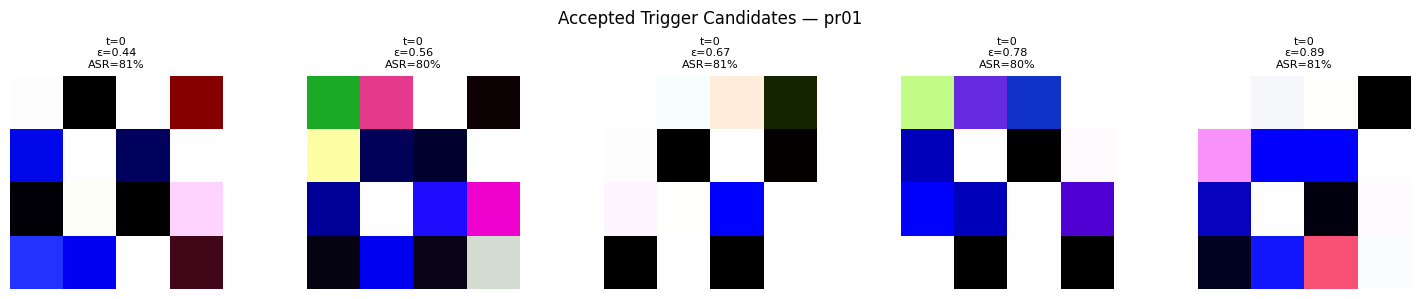

  Saved: /content/drive/MyDrive/Capstone/BadNets_Final/defense/baeraser/trigger_figures/baeraser_trigger_recovery_pr01.png


In [14]:
# ════════════════════════════════════════════════════════════════════════
# Cell H1 — pr01: Trigger Recovery + Diagnostics (RUN FIRST)
# ════════════════════════════════════════════════════════════════════════
_tag = 'pr01'
set_seed(SEED)

# Stage 1: Trigger Recovery (Exact Candidate Selection)
trigger_pool_pr01, candidates_pr01 = run_trigger_recovery(_tag)

# Diagnostics — STOP AND READ BEFORE PROCEEDING
print('\n' + '='*65)
print('TRIGGER RECOVERY DIAGNOSTICS — pr01')
print('='*65)
print(f'  Candidate generators trained: {len(candidates_pr01)}')
print(f'  Accepted (ASR ≥ {BAERASER_RECOVERY_ASR_THRESHOLD*100:.0f}%):  {len(trigger_pool_pr01)}')

if trigger_pool_pr01:
    for i, tp in enumerate(trigger_pool_pr01):
        print(f'\n  Accepted #{i+1}:')
        print(f'    target_label = {tp["target_label"]}')
        print(f'    epsilon      = {tp["epsilon"]:.4f}')
        print(f'    candidate ASR = {tp["asr"]*100:.2f}%')
        t = tp['tensor']
        print(f'    trigger mean  = {t.mean():.4f}')
        print(f'    trigger std   = {t.std():.4f}')
        print(f'    trigger min   = {t.min():.4f}')
        print(f'    trigger max   = {t.max():.4f}')
    plot_trigger_recovery_diagnostics(trigger_pool_pr01, candidates_pr01, _tag)
else:
    print('\n  ⚠️  NO TRIGGER CANDIDATES ACCEPTED!')
    print('  Cannot proceed with unlearning.')
    print('  Check:')
    print('    - Is the victim model actually backdoored?')
    print('    - Is BAERASER_RECOVERY_ASR_THRESHOLD too high?')
    print('    - Are trigger recovery epochs sufficient?')
print('='*65)

In [31]:
# ════════════════════════════════════════════════════════════════════════
# Cell H2 — pr01: BaEraser Unlearning
# ════════════════════════════════════════════════════════════════════════
if not trigger_pool_pr01:
    raise RuntimeError(
        'pr01 trigger recovery produced NO accepted candidates. '
        'Cannot proceed with unlearning.')

set_seed(SEED)
best_ckpt_pr01, unlearn_logs_pr01, result_pr01 = baeraser_unlearning(
    'pr01', trigger_pool_pr01)

# Checkpoint reload verification
if best_ckpt_pr01 and result_pr01['status'] == 'SUCCESS':
    _v = get_resnet18().to(DEVICE)
    _v.load_state_dict(torch.load(best_ckpt_pr01, map_location=DEVICE))
    _v_ca, _v_asr = evaluate_model(_v)
    print(f'\n  Reload verification: CA={_v_ca*100:.2f}%, ASR={_v_asr*100:.2f}%')
    assert abs(_v_ca - result_pr01['CA_after']) < 0.002, \
        f'CA mismatch: {_v_ca:.4f} vs {result_pr01["CA_after"]:.4f}'
    del _v; torch.cuda.empty_cache()
    print('  Checkpoint reload verification PASSED ✓')


BAERASER UNLEARNING: pr01
  α=1.0, β=1.0, β/α=1.0000
  Trigger pool size: 5
  Recovered target label: 0

  Epoch   CleanCE    TrigCE   Penalty    TotalL       CA      ASR  ParamDist
  ---------------------------------------------------------------------------
      1    0.1033    6.2033    0.0317   -6.0682   0.8830   0.5330     0.2124  (11.6s)
      2    0.0961    7.1457    0.2479   -6.8017   0.8860   0.4420     0.5065  (13.1s)
      3    0.0837    8.1758    0.3848   -7.7073   0.8868   0.3350     0.7946  (12.3s)
      4    0.0886    9.1789    0.5194   -8.5709   0.8829   0.2380     1.0651  (12.1s)
      5    0.0816   10.1864    0.6932   -9.4116   0.8905   0.1520     1.3105  (12.2s)
      6    0.0859   11.0466    0.6802  -10.2805   0.8850   0.1120     1.5476  (12.4s)
      7    0.1091   11.8748    0.8930  -10.8727   0.8852   0.0610     1.7674  (13.5s)
      8    0.1064   12.8230    0.9791  -11.7374   0.8849   0.0510     1.9639  (13.6s)
      9    0.1129   13.5889    1.0635  -12.4124   0


TRIGGER RECOVERY: pr05 | mode=A
  Target labels: [0]
  Epsilon count: 10
  Placement: random

  --- target=0, ε=0.00 ---
    [Ep  1] hinge=0.0000 MI=0.0900 prob_target=0.1229
    [Ep  2] hinge=0.0000 MI=0.4551 prob_target=0.1480
    [Ep  4] hinge=0.0000 MI=1.9809 prob_target=0.1558
    [Ep  6] hinge=0.0000 MI=2.8969 prob_target=0.1619
    [Ep  8] hinge=0.0000 MI=3.0148 prob_target=0.1547
    [Ep 10] hinge=0.0000 MI=3.7844 prob_target=0.1626
    Exact Candidate ASR: 39.84%  [✗ rejected]
    Trigger: mean=0.4698 std=0.3906 norm=4.2150

  --- target=0, ε=0.11 ---
    [Ep  1] hinge=0.0497 MI=0.0379 prob_target=0.4360
    [Ep  2] hinge=0.0171 MI=0.1769 prob_target=0.7282
    [Ep  4] hinge=0.0115 MI=0.7280 prob_target=0.7810
    [Ep  6] hinge=0.0151 MI=1.2443 prob_target=0.7386
    [Ep  8] hinge=0.0187 MI=1.7464 prob_target=0.6920
    [Ep 10] hinge=0.0190 MI=2.0872 prob_target=0.6949
    Exact Candidate ASR: 86.41%  [✓ ACCEPTED]
    Trigger: mean=0.4560 std=0.4456 norm=4.3949

  --- target=

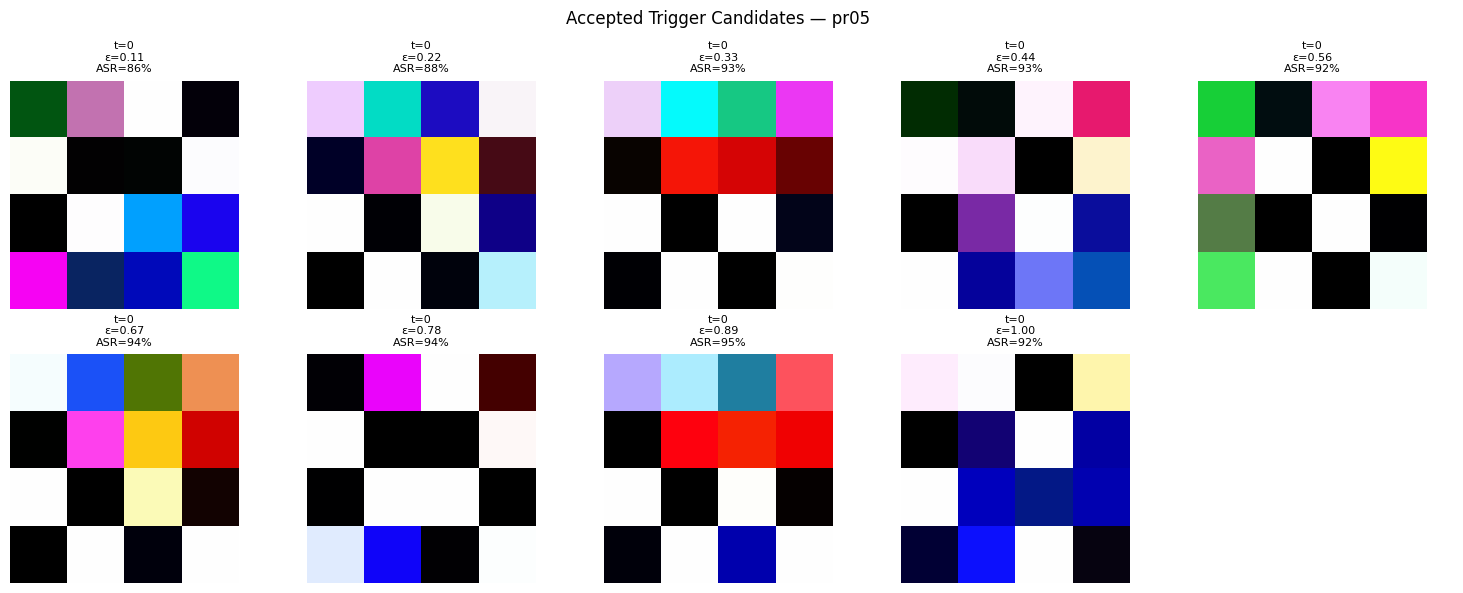

  Saved: /content/drive/MyDrive/Capstone/BadNets_Final/defense/baeraser/trigger_figures/baeraser_trigger_recovery_pr05.png

BAERASER UNLEARNING: pr05
  α=1.0, β=1.0, β/α=1.0000
  Trigger pool size: 9
  Recovered target label: 0

  Epoch   CleanCE    TrigCE   Penalty    TotalL       CA      ASR  ParamDist
  ---------------------------------------------------------------------------
      1    0.1728    4.2184    0.0367   -4.0088   0.8765   0.9020     0.1955  (11.5s)
      2    0.1509    5.0498    0.2272   -4.6718   0.8819   0.8690     0.4720  (12.8s)
      3    0.1193    6.0300    0.3455   -5.5652   0.8826   0.7940     0.7356  (13.1s)
      4    0.1120    6.9248    0.4530   -6.3598   0.8806   0.6460     0.9882  (12.5s)
      5    0.1076    7.8668    0.5888   -7.1703   0.8871   0.4010     1.2183  (11.9s)
      6    0.1108    8.6594    0.5866   -7.9620   0.8840   0.2750     1.4414  (11.6s)
      7    0.1227    9.5042    0.7562   -8.6253   0.8833   0.1570     1.6511  (11.7s)
      8    0.1

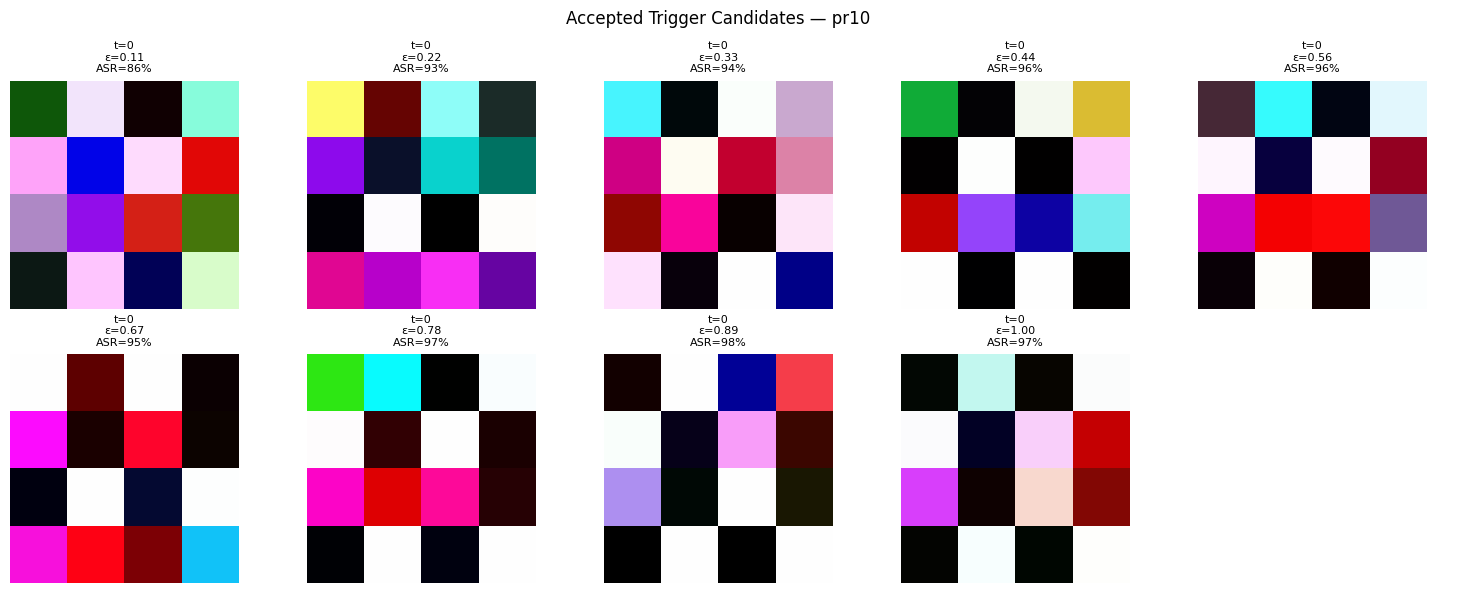

  Saved: /content/drive/MyDrive/Capstone/BadNets_Final/defense/baeraser/trigger_figures/baeraser_trigger_recovery_pr10.png

BAERASER UNLEARNING: pr10
  α=1.0, β=1.0, β/α=1.0000
  Trigger pool size: 9
  Recovered target label: 0

  Epoch   CleanCE    TrigCE   Penalty    TotalL       CA      ASR  ParamDist
  ---------------------------------------------------------------------------
      1    0.3362    3.1796    0.0419   -2.8015   0.8719   0.9520     0.2176  (11.5s)
      2    0.2300    4.0336    0.2729   -3.5308   0.8790   0.9340     0.5196  (12.6s)
      3    0.1504    4.9923    0.3804   -4.4616   0.8823   0.9090     0.8032  (13.2s)
      4    0.1340    5.8888    0.4607   -5.2941   0.8809   0.8390     1.0655  (13.1s)
      5    0.1124    6.8326    0.5579   -6.1623   0.8877   0.6390     1.2956  (12.7s)
      6    0.1197    7.6552    0.5660   -6.9695   0.8835   0.4290     1.5141  (12.2s)
      7    0.1164    8.4816    0.7120   -7.6531   0.8838   0.2670     1.7153  (12.4s)
      8    0.1

In [32]:
# ════════════════════════════════════════════════════════════════════════
# Cell H3 — Full BaEraser Pipeline for pr05 and pr10
# ════════════════════════════════════════════════════════════════════════

# Store all results
all_trigger_pools = {'pr01': trigger_pool_pr01}
all_candidates    = {'pr01': candidates_pr01}
all_unlearn_logs  = {'pr01': unlearn_logs_pr01}
all_results       = {'pr01': result_pr01}
all_best_ckpts    = {'pr01': best_ckpt_pr01}

for _tag in ['pr05', 'pr10']:
    set_seed(SEED)

    # Stage 1: Trigger Recovery (Exact Candidate Selection)
    tp, cands = run_trigger_recovery(_tag)
    all_trigger_pools[_tag] = tp
    all_candidates[_tag] = cands

    if tp:
        plot_trigger_recovery_diagnostics(tp, cands, _tag)
    else:
        print(f'  ⚠️ No accepted triggers for {_tag}. Marking as FAILED.')

    # Stage 2: Unlearning
    if tp:
        set_seed(SEED)
        ckpt, logs, result = baeraser_unlearning(_tag, tp)
        all_best_ckpts[_tag] = ckpt
        all_unlearn_logs[_tag] = logs
        all_results[_tag] = result

        # Reload verification
        if ckpt and result['status'] == 'SUCCESS':
            _v = get_resnet18().to(DEVICE)
            _v.load_state_dict(torch.load(ckpt, map_location=DEVICE))
            _v_ca, _v_asr = evaluate_model(_v)
            assert abs(_v_ca - result['CA_after']) < 0.002, 'CA mismatch'
            del _v; torch.cuda.empty_cache()
            print(f'  Checkpoint reload verification PASSED ✓ ({_tag})')
    else:
        all_best_ckpts[_tag] = None
        all_unlearn_logs[_tag] = []
        all_results[_tag] = {
            'pr_tag': _tag, 'status': 'FAILED_NO_TRIGGERS',
            'CA_before': baseline_results[_tag]['CA_before'],
            'ASR_before': baseline_results[_tag]['ASR_before'],
        }

print('\nFull BaEraser pipeline complete for all rates.')

---
## Section I — BaEraser Results & Plots

In [33]:
# ════════════════════════════════════════════════════════════════════════
# Cell I1 — Master Results Table
# ════════════════════════════════════════════════════════════════════════
master_rows = []

for _tag in PR_TAGS:
    _r = all_results[_tag]
    row = {
        'attack': ATTACK_NAME,
        'poison_rate': PR_MAP[_tag],
        'pr_tag': _tag,
        'CA_before': _r.get('CA_before'),
        'ASR_before': _r.get('ASR_before'),
        'CA_after': _r.get('CA_after'),
        'ASR_after': _r.get('ASR_after'),
        'CA_drop': _r.get('CA_drop'),
        'ASR_reduction_absolute': _r.get('ASR_reduction_abs'),
        'ASR_reduction_relative': _r.get('ASR_reduction_rel'),
        'recovered_trigger_count': len(all_candidates.get(_tag, [])),
        'accepted_trigger_count': len(all_trigger_pools.get(_tag, [])),
        'beta_alpha_ratio': round(BAERASER_BETA / BAERASER_ALPHA, 6),
        'unlearning_epochs': _r.get('best_epoch'),
        'best_checkpoint': os.path.basename(_r.get('checkpoint', '') or ''),
        'defense_samples': len(defense_set),
        'recovery_target_mode': BAERASER_RECOVERY_MODE,
        'recovery_placement': BAERASER_RECOVERY_PLACEMENT,
        'trigger_height': BAERASER_TRIGGER_HEIGHT,
        'trigger_width': BAERASER_TRIGGER_WIDTH,
        'status': _r.get('status', 'UNKNOWN'),
    }
    master_rows.append(row)

master_df = pd.DataFrame(master_rows)
_master_csv = f'{BAERASER_CSV_DIR}/badnets_baeraser_master_results.csv'
master_df.to_csv(_master_csv, index=False)

print('BAERASER DEFENCE RESULTS')
print('='*90)
_show = ['pr_tag','CA_before','ASR_before','CA_after','ASR_after',
         'CA_drop','ASR_reduction_absolute','accepted_trigger_count',
         'unlearning_epochs','status']
_av = [c for c in _show if c in master_df.columns]
print(master_df[_av].to_string(index=False))
print(f'\nSaved: {_master_csv}')

BAERASER DEFENCE RESULTS
pr_tag  CA_before  ASR_before  CA_after  ASR_after  CA_drop  ASR_reduction_absolute  accepted_trigger_count  unlearning_epochs  status
  pr01     0.9028       0.827    0.8726      0.008   0.0302                   0.819                       5                 13 SUCCESS
  pr05     0.8981       0.954    0.8670      0.009   0.0311                   0.945                       9                 15 SUCCESS
  pr10     0.8959       0.961    0.8672      0.009   0.0287                   0.952                       9                 14 SUCCESS

Saved: /content/drive/MyDrive/Capstone/BadNets_Final/defense/baeraser/csv/badnets_baeraser_master_results.csv


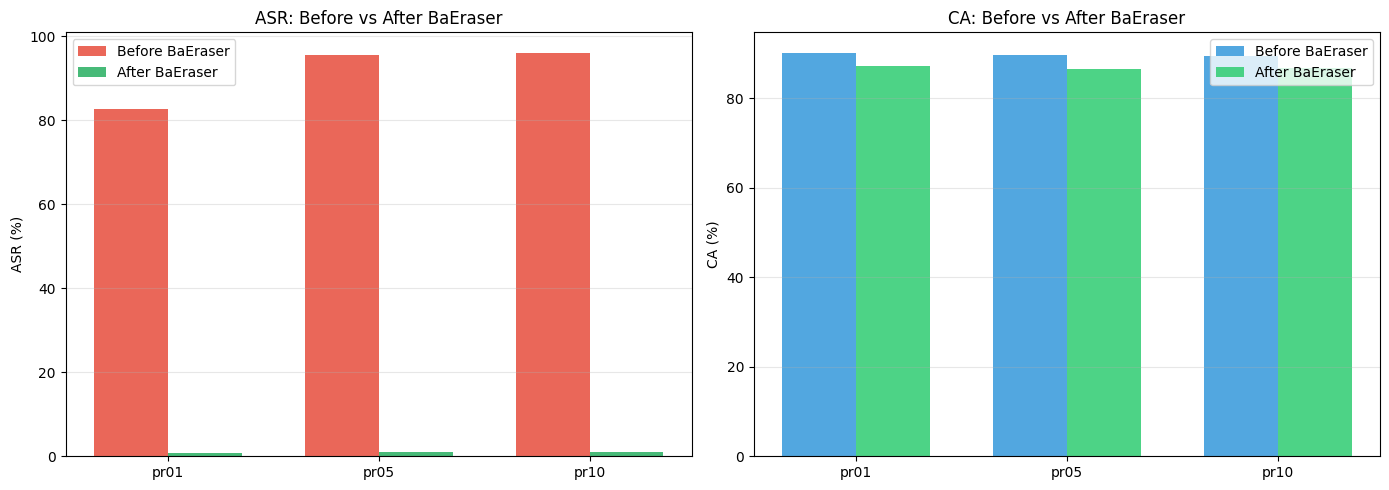

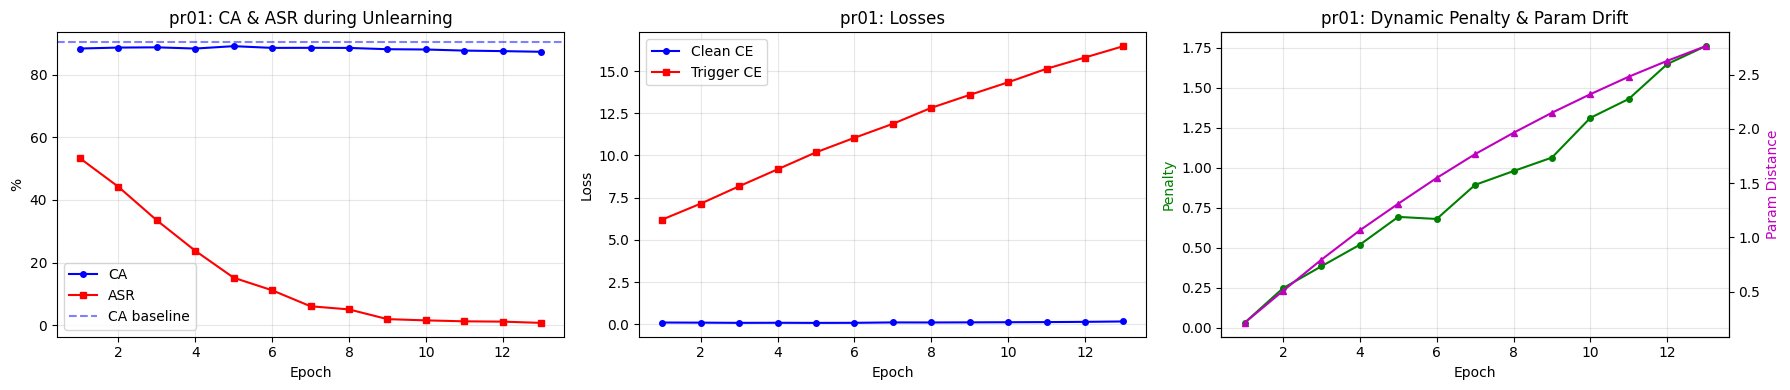

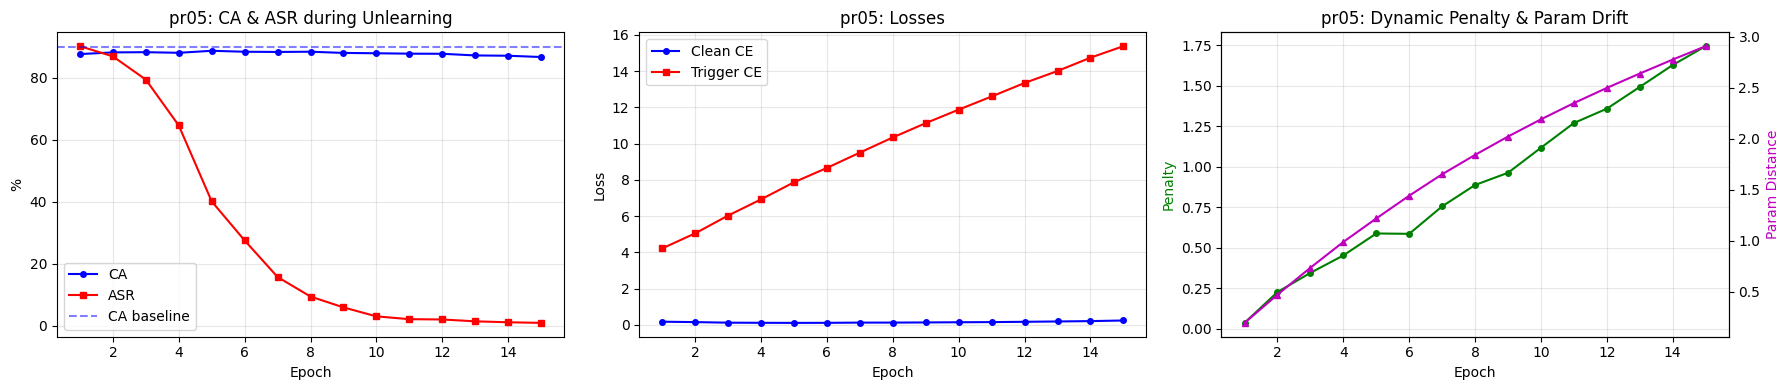

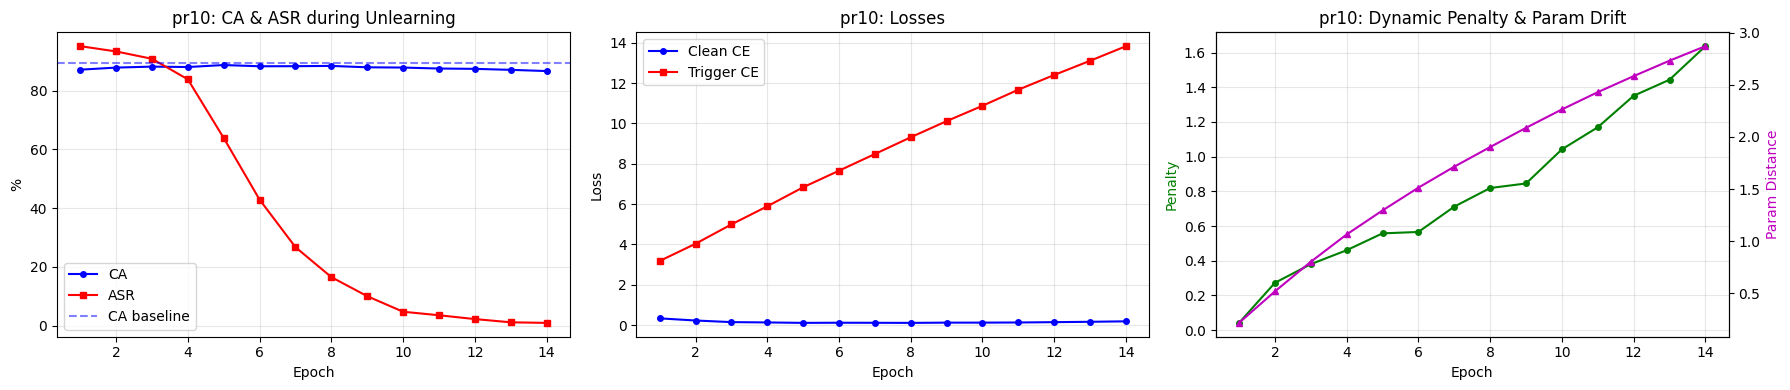

In [34]:
# ════════════════════════════════════════════════════════════════════════
# Cell I2 — CA/ASR Comparison Plots + Unlearning Curves
# ════════════════════════════════════════════════════════════════════════

# Bar charts: Before vs After
_valid_tags = [t for t in PR_TAGS if all_results[t].get('status') == 'SUCCESS']

if _valid_tags:
    x = np.arange(len(_valid_tags))
    w = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(x-w/2,
                [baseline_results[t]['ASR_before']*100 for t in _valid_tags],
                w, label='Before BaEraser', color='#e74c3c', alpha=0.85)
    axes[0].bar(x+w/2,
                [all_results[t]['ASR_after']*100 for t in _valid_tags],
                w, label='After BaEraser', color='#27ae60', alpha=0.85)
    axes[0].set_ylabel('ASR (%)')
    axes[0].set_title('ASR: Before vs After BaEraser')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(_valid_tags)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar(x-w/2,
                [baseline_results[t]['CA_before']*100 for t in _valid_tags],
                w, label='Before BaEraser', color='#3498db', alpha=0.85)
    axes[1].bar(x+w/2,
                [all_results[t]['CA_after']*100 for t in _valid_tags],
                w, label='After BaEraser', color='#2ecc71', alpha=0.85)
    axes[1].set_ylabel('CA (%)')
    axes[1].set_title('CA: Before vs After BaEraser')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(_valid_tags)
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{BAERASER_FIG_DIR}/baeraser_asr_ca_comparison.png',
                dpi=150, bbox_inches='tight')
    plt.show()

# Unlearning curves per poison rate
for _tag in PR_TAGS:
    _logs = all_unlearn_logs.get(_tag, [])
    if not _logs:
        continue
    df = pd.DataFrame(_logs)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # CA + ASR
    axes[0].plot(df['epoch'], df['clean_acc']*100, 'b-o', label='CA', markersize=4)
    axes[0].plot(df['epoch'], df['asr']*100, 'r-s', label='ASR', markersize=4)
    axes[0].axhline(y=baseline_results[_tag]['CA_before']*100,
                     color='b', linestyle='--', alpha=0.5, label='CA baseline')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('%')
    axes[0].set_title(f'{_tag}: CA & ASR during Unlearning')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Losses
    axes[1].plot(df['epoch'], df['clean_loss'], 'b-o', label='Clean CE', markersize=4)
    axes[1].plot(df['epoch'], df['trigger_loss'], 'r-s', label='Trigger CE', markersize=4)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title(f'{_tag}: Losses')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Penalty + param distance
    ax2 = axes[2].twinx()
    axes[2].plot(df['epoch'], df['penalty'], 'g-o', label='Penalty', markersize=4)
    ax2.plot(df['epoch'], df['param_dist'], 'm-^', label='Param Dist', markersize=4)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Penalty', color='g')
    ax2.set_ylabel('Param Distance', color='m')
    axes[2].set_title(f'{_tag}: Dynamic Penalty & Param Drift')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{BAERASER_FIG_DIR}/baeraser_unlearning_ca_asr_{_tag}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

---
## Section J — STRIP Diagnostic (Before/After)

STRIP is a **behavioural diagnostic only**, NOT the primary defence.
Run before/after on VALID defended models.


=== STRIP: pr01 ===
Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:04<00:00, 23.01it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:03<00:00, 25.50it/s]



STRIP Results:
  Clean entropy — mean: 0.6454, std: 0.1509
  Threshold (FRR=1%): 0.2943
  Min clean entropy:     0.2962
  Max triggered entropy: 0.9855
  TPR (detection rate):  12.00%
  FPR (false alarms):    0.00%
Saved: /content/drive/MyDrive/Capstone/BadNets_Final/defense/strip/before/strip_before_pr01.png


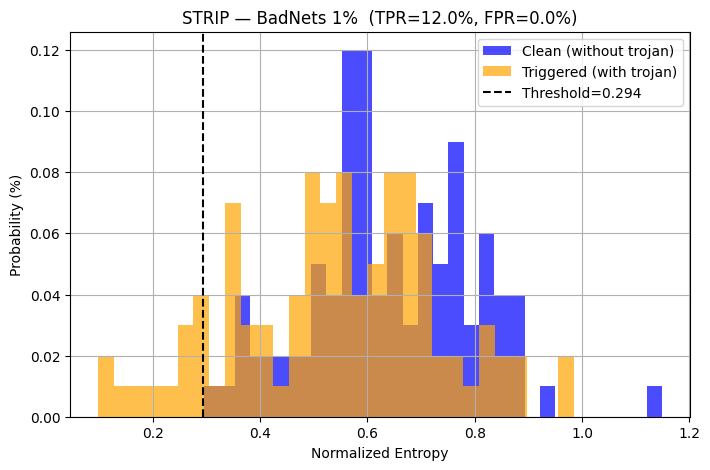

Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:03<00:00, 28.23it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:03<00:00, 25.20it/s]



STRIP Results:
  Clean entropy — mean: 0.5184, std: 0.1395
  Threshold (FRR=1%): 0.1939
  Min clean entropy:     0.1733
  Max triggered entropy: 1.0020
  TPR (detection rate):  4.00%
  FPR (false alarms):    1.00%
Saved: /content/drive/MyDrive/Capstone/BadNets_Final/defense/strip/after/strip_after_pr01.png


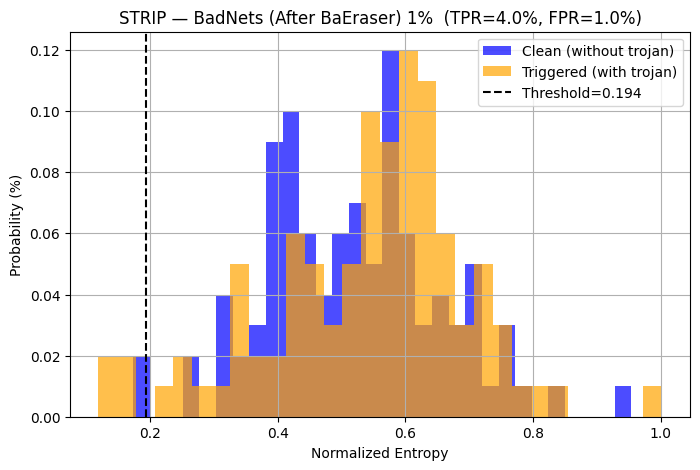

  BEFORE: TPR=12.00%  mu=0.6454
  AFTER:  TPR=4.00%  mu=0.5184

=== STRIP: pr05 ===
Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:04<00:00, 23.63it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:03<00:00, 27.40it/s]



STRIP Results:
  Clean entropy — mean: 0.6793, std: 0.1602
  Threshold (FRR=1%): 0.3065
  Min clean entropy:     0.3286
  Max triggered entropy: 1.0523
  TPR (detection rate):  22.00%
  FPR (false alarms):    0.00%
Saved: /content/drive/MyDrive/Capstone/BadNets_Final/defense/strip/before/strip_before_pr05.png


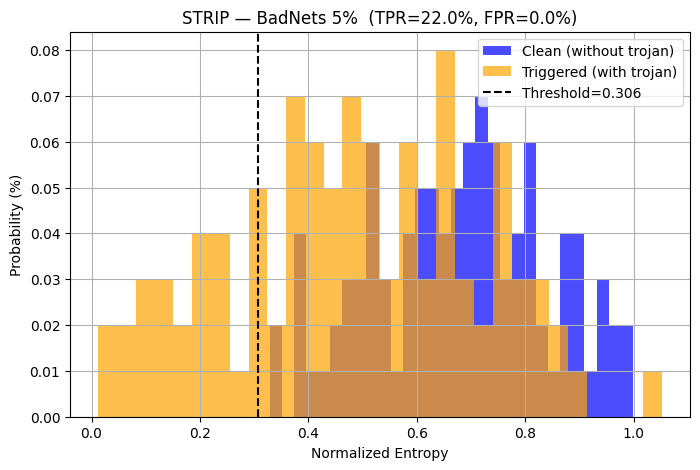

Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:03<00:00, 26.62it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:04<00:00, 23.36it/s]



STRIP Results:
  Clean entropy — mean: 0.5654, std: 0.1452
  Threshold (FRR=1%): 0.2277
  Min clean entropy:     0.2728
  Max triggered entropy: 1.0633
  TPR (detection rate):  0.00%
  FPR (false alarms):    0.00%
Saved: /content/drive/MyDrive/Capstone/BadNets_Final/defense/strip/after/strip_after_pr05.png


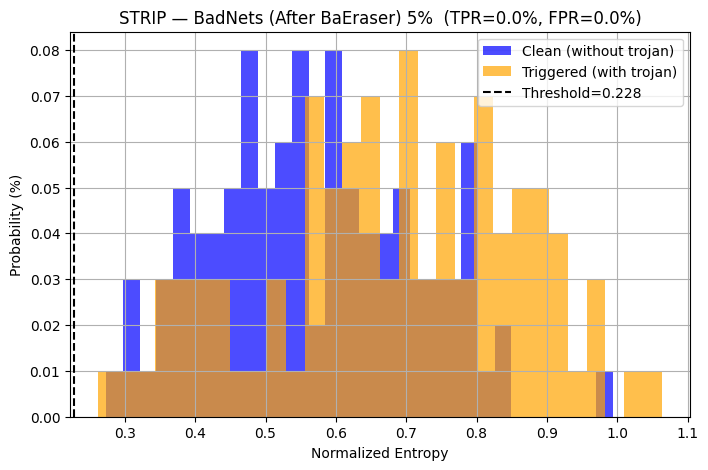

  BEFORE: TPR=22.00%  mu=0.6793
  AFTER:  TPR=0.00%  mu=0.5654

=== STRIP: pr10 ===
Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:03<00:00, 27.12it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:03<00:00, 27.82it/s]



STRIP Results:
  Clean entropy — mean: 0.6910, std: 0.1617
  Threshold (FRR=1%): 0.3148
  Min clean entropy:     0.0665
  Max triggered entropy: 0.9977
  TPR (detection rate):  36.00%
  FPR (false alarms):    1.00%
Saved: /content/drive/MyDrive/Capstone/BadNets_Final/defense/strip/before/strip_before_pr10.png


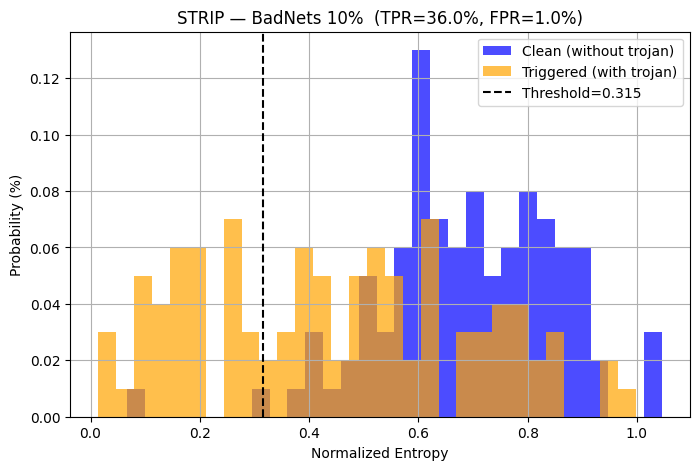

Running STRIP on 100 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 100/100 [00:04<00:00, 23.67it/s]


Running STRIP on 100 clean samples...


100%|██████████| 100/100 [00:03<00:00, 25.60it/s]



STRIP Results:
  Clean entropy — mean: 0.6153, std: 0.1609
  Threshold (FRR=1%): 0.2410
  Min clean entropy:     0.2928
  Max triggered entropy: 1.4047
  TPR (detection rate):  1.00%
  FPR (false alarms):    0.00%
Saved: /content/drive/MyDrive/Capstone/BadNets_Final/defense/strip/after/strip_after_pr10.png


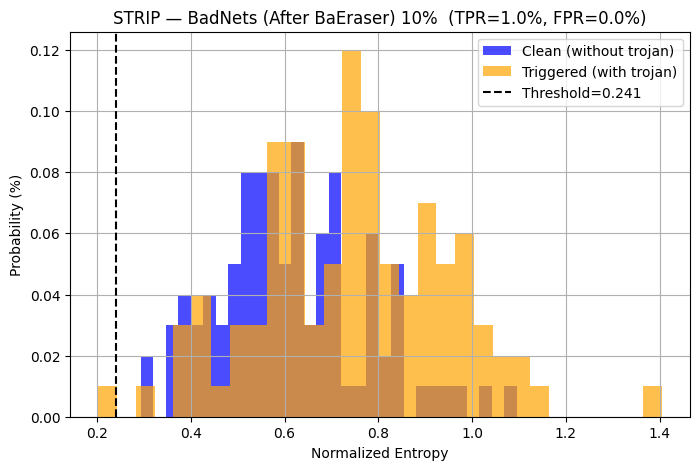

  BEFORE: TPR=36.00%  mu=0.6910
  AFTER:  TPR=1.00%  mu=0.6153


In [35]:
# ════════════════════════════════════════════════════════════════════════
# Cell J1 — STRIP Before/After
# ════════════════════════════════════════════════════════════════════════
STRIP_N_SAMPLES     = 200
STRIP_N_SUPERIMPOSE = 50
STRIP_FRR           = 0.01
STRIP_BATCH_SIZE    = 100

def _badnets_trigger_fn(img):
    return add_badnets_trigger(img, trigger_size=TRIGGER_SIZE)

strip_rows = []

for _tag in PR_TAGS:
    print(f'\n=== STRIP: {_tag} ===')

    if all_results[_tag].get('status') != 'SUCCESS':
        print(f'  BaEraser failed for {_tag}. STRIP comparison NOT valid.')
        strip_rows.append({'pr_tag': _tag, 'poison_rate': PR_MAP[_tag],
                           'status': 'BAERASER_FAILED',
                           'TPR_before': None, 'TPR_after': None})
        continue

    # BEFORE: original backdoored model
    _m_b = load_backdoored_model(_tag, DEVICE)
    _s_b = run_strip(
        model=_m_b, test_dataset_raw=testset_raw,
        clean_dataset_raw=testset_raw, device=DEVICE,
        transform=transform_test, target_class=TARGET_CLASS,
        trigger_fn=_badnets_trigger_fn, asr_test_idx=asr_test_idx,
        n_samples=STRIP_N_SAMPLES, n_superimpose=STRIP_N_SUPERIMPOSE,
        frr=STRIP_FRR, seed=SEED, batch_size=STRIP_BATCH_SIZE)
    np.save(f'{STRIP_BEFORE_DIR}/strip_before_{_tag}.npy', _s_b['entropies'])
    plot_strip_results(_s_b, ATTACK_NAME, PR_MAP[_tag],
                       save_path=f'{STRIP_BEFORE_DIR}/strip_before_{_tag}.png')
    del _m_b; torch.cuda.empty_cache()

    # AFTER: BaEraser defended model
    _m_a = get_resnet18().to(DEVICE)
    _m_a.load_state_dict(torch.load(
        all_best_ckpts[_tag], map_location=DEVICE))
    _m_a.eval()
    _s_a = run_strip(
        model=_m_a, test_dataset_raw=testset_raw,
        clean_dataset_raw=testset_raw, device=DEVICE,
        transform=transform_test, target_class=TARGET_CLASS,
        trigger_fn=_badnets_trigger_fn, asr_test_idx=asr_test_idx,
        n_samples=STRIP_N_SAMPLES, n_superimpose=STRIP_N_SUPERIMPOSE,
        frr=STRIP_FRR, seed=SEED, batch_size=STRIP_BATCH_SIZE)
    np.save(f'{STRIP_AFTER_DIR}/strip_after_{_tag}.npy', _s_a['entropies'])
    plot_strip_results(_s_a, f'{ATTACK_NAME} (After BaEraser)', PR_MAP[_tag],
                       save_path=f'{STRIP_AFTER_DIR}/strip_after_{_tag}.png')
    del _m_a; torch.cuda.empty_cache()

    strip_rows.append({
        'pr_tag': _tag, 'poison_rate': PR_MAP[_tag], 'status': 'OK',
        'TPR_before': _s_b['TPR'], 'TPR_after': _s_a['TPR'],
        'mu_before': _s_b['mu'], 'mu_after': _s_a['mu'],
    })
    print(f'  BEFORE: TPR={_s_b["TPR"]:.2f}%  mu={_s_b["mu"]:.4f}')
    print(f'  AFTER:  TPR={_s_a["TPR"]:.2f}%  mu={_s_a["mu"]:.4f}')

pd.DataFrame(strip_rows).to_csv(
    f'{BAERASER_CSV_DIR}/badnets_baeraser_strip.csv', index=False)

---
## Section K — Grad-CAM Diagnostic (Before/After)

Grad-CAM is **interpretability evidence only**. Shows:
`Clean BEFORE · Clean AFTER · Triggered BEFORE · Triggered AFTER`


Grad-CAM: pr01


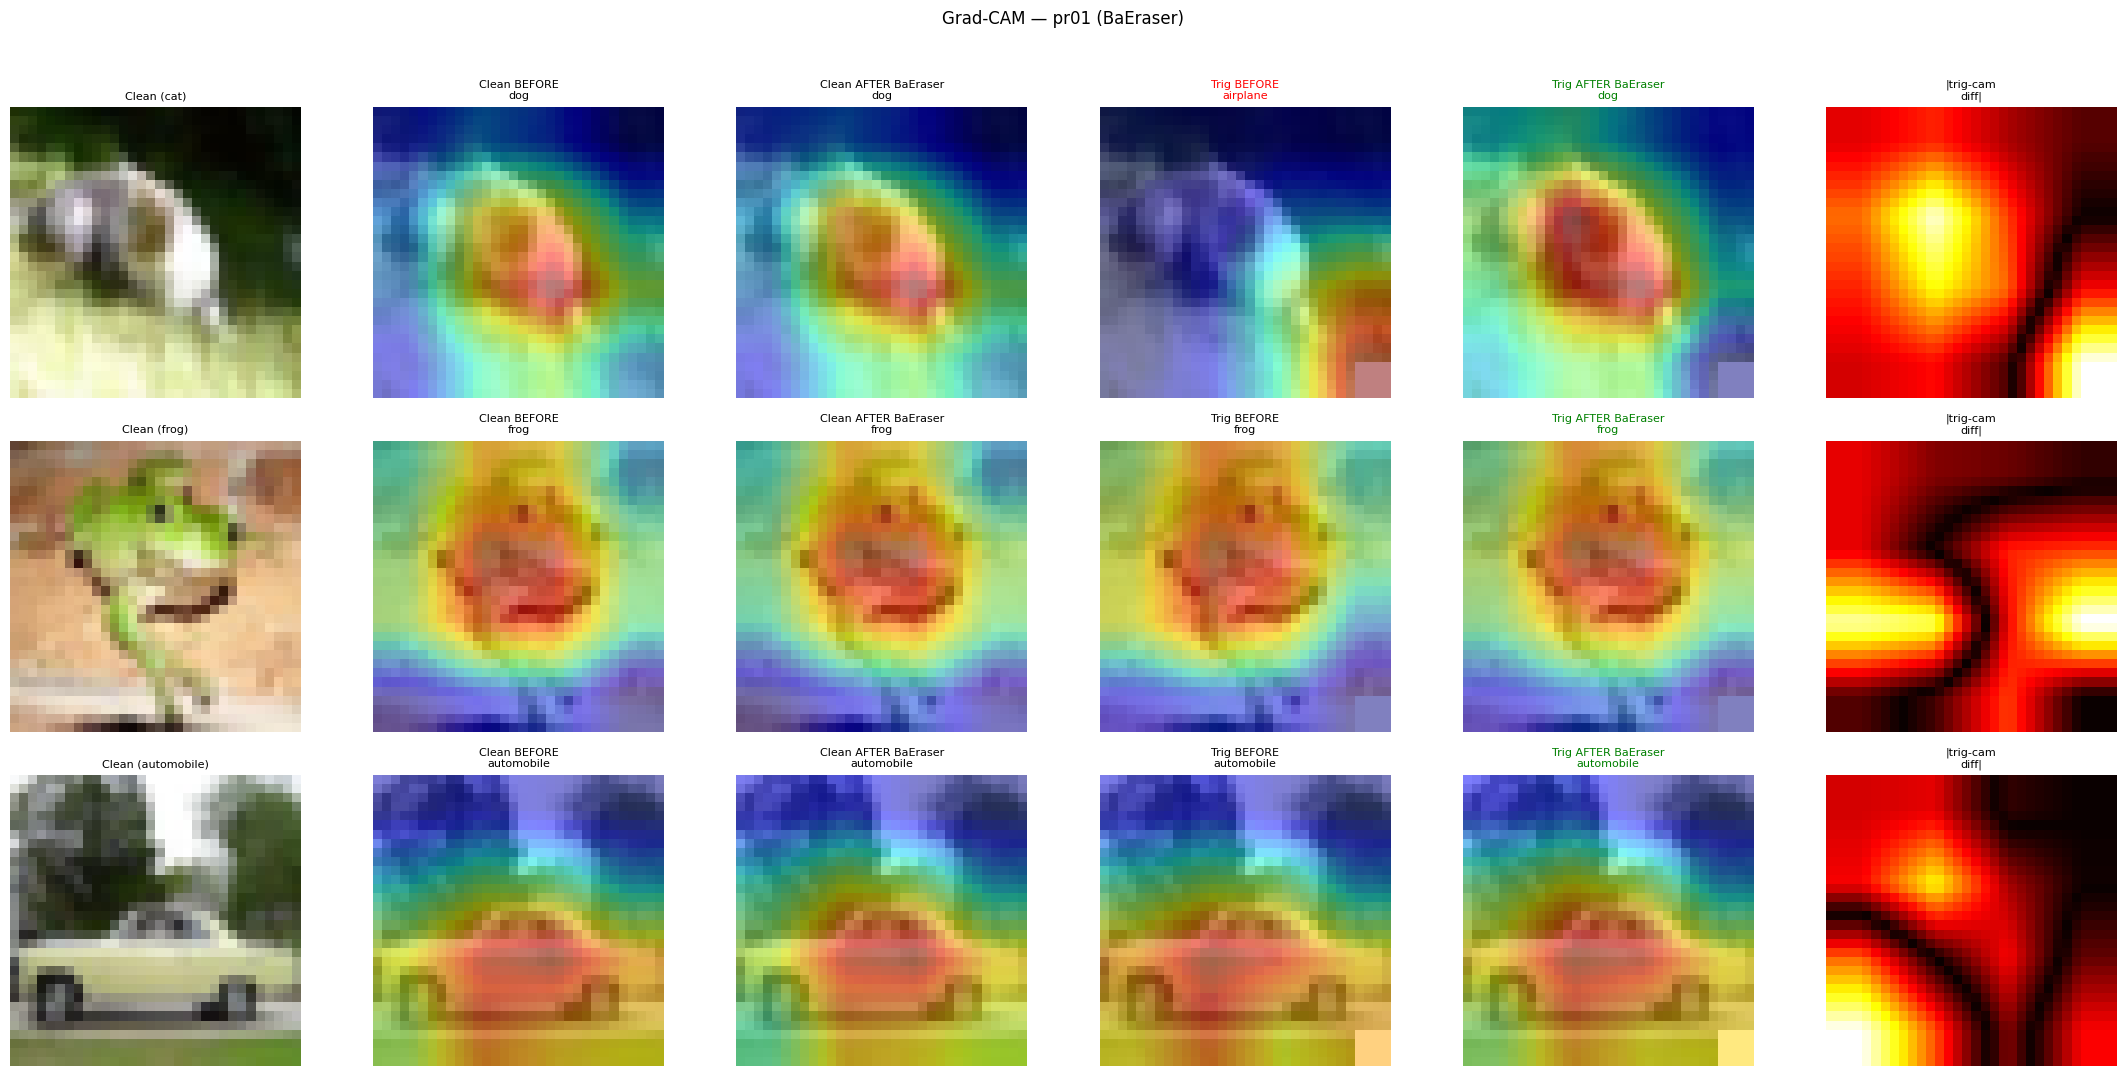


Grad-CAM: pr05


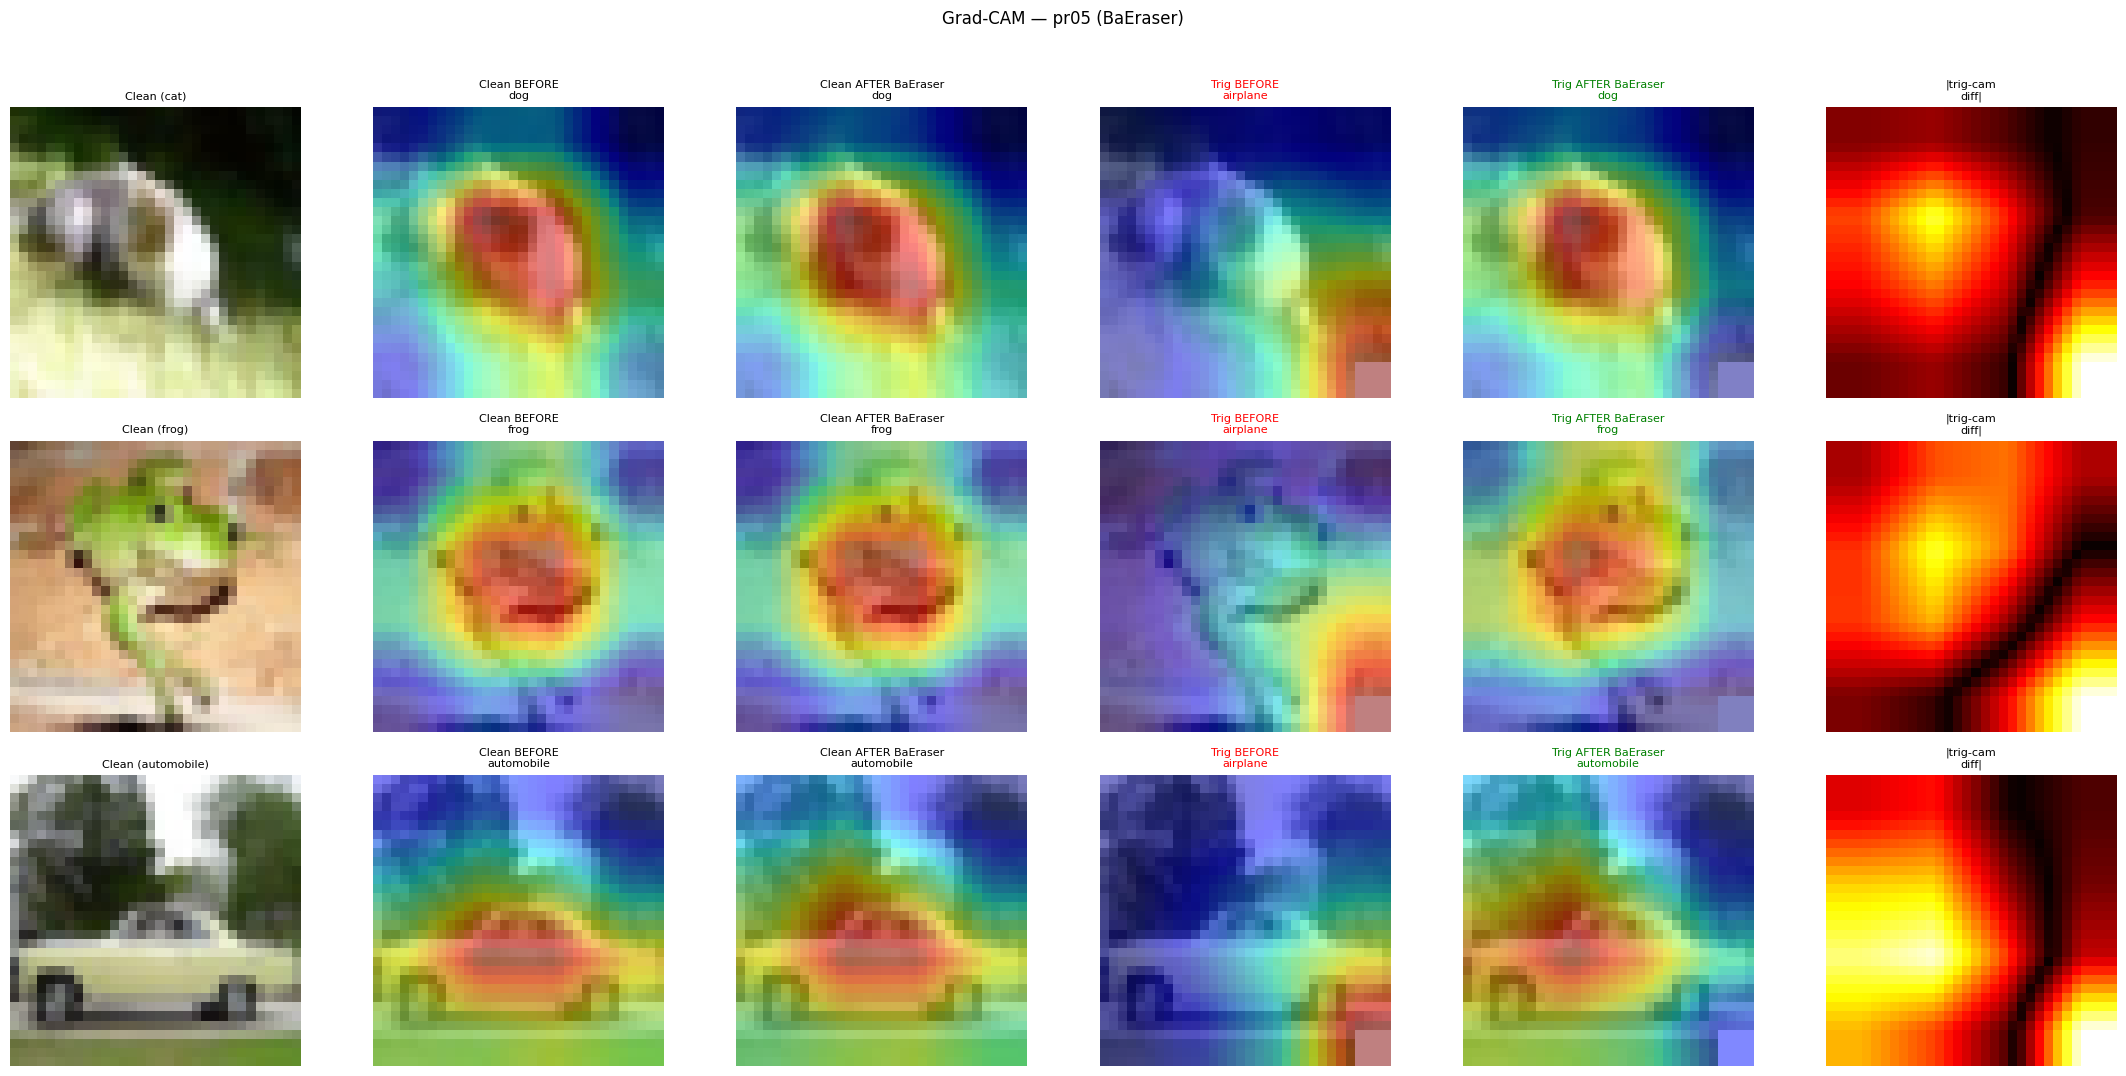


Grad-CAM: pr10


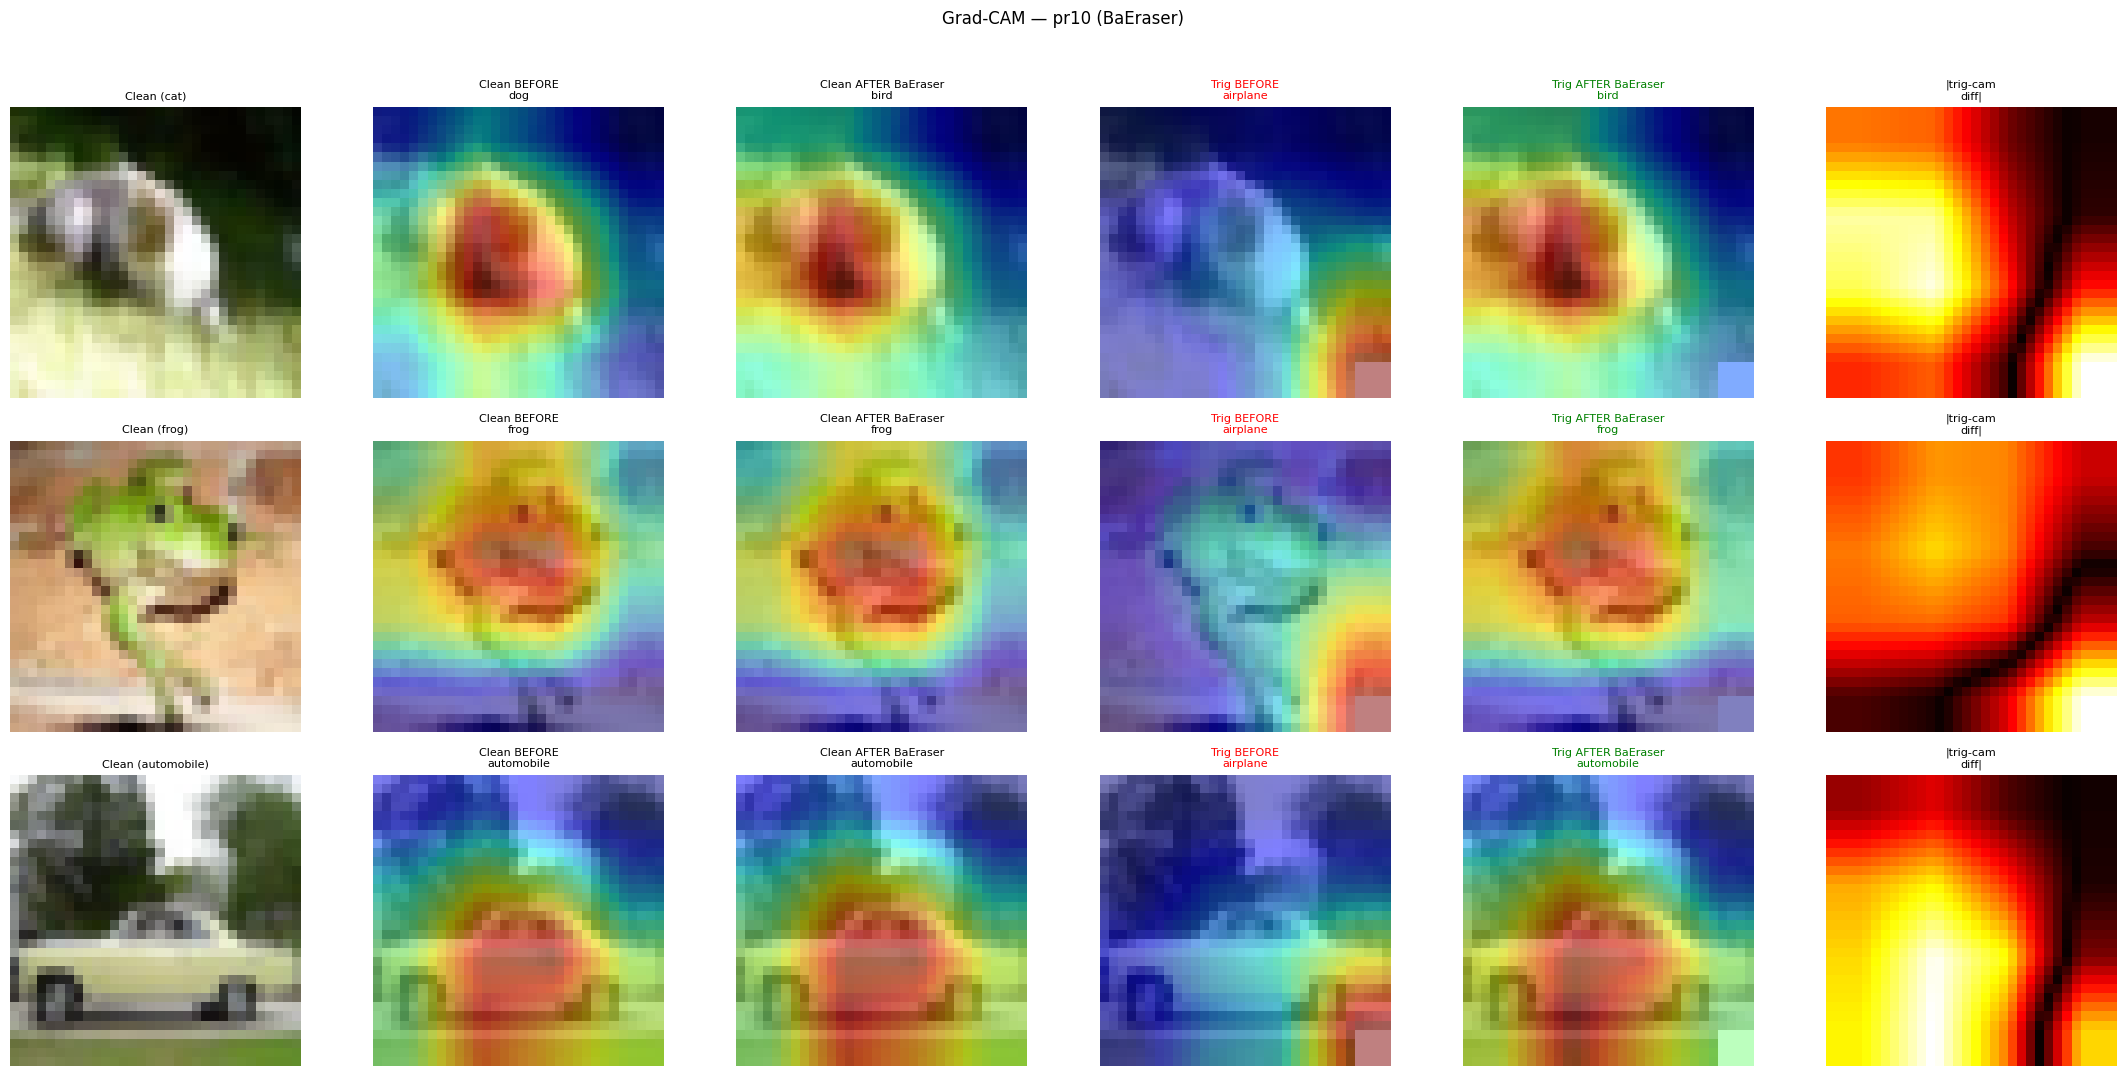

In [36]:
# ════════════════════════════════════════════════════════════════════════
# Cell K1 — Grad-CAM: Clean BEFORE/AFTER + Triggered BEFORE/AFTER
# ════════════════════════════════════════════════════════════════════════

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']
N_VIS_SAMPLES   = 3
GRADCAM_LAYER   = 'layer4'

class GradCAM:
    def __init__(self, model, layer_name=GRADCAM_LAYER):
        self.model = model; self.activations = None; self.gradients = None
        layer = dict(model.named_modules())[layer_name]
        layer.register_forward_hook(self._save_act)
        layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, inp, out): self.activations = out.detach()
    def _save_grad(self, m, gi, go):  self.gradients = go[0].detach()

    def __call__(self, x, target_class=None):
        self.model.zero_grad()
        out = self.model(x)
        pred = out.argmax(dim=1).item()
        tc = target_class if target_class is not None else pred
        out[0, tc].backward()
        w   = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = F.relu((w * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(32,32), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, pred

def img_to_tensor(img_uint8):
    t = torch.from_numpy(img_uint8.astype(np.float32)/255.0).permute(2,0,1)
    mean = torch.tensor(list(CIFAR_MEAN)).view(3,1,1)
    std  = torch.tensor(list(CIFAR_STD)).view(3,1,1)
    return ((t - mean) / std).unsqueeze(0).to(DEVICE)

_rng_vis = np.random.RandomState(SEED)
vis_indices = _rng_vis.choice(asr_test_idx, size=N_VIS_SAMPLES, replace=False)

gradcam_rows = []

for _tag in PR_TAGS:
    print(f'\nGrad-CAM: {_tag}')
    if all_results[_tag].get('status') != 'SUCCESS':
        print(f'  BaEraser failed for {_tag}. Grad-CAM comparison NOT valid.')
        continue

    _m_b = load_backdoored_model(_tag, DEVICE)
    _cam_b = GradCAM(_m_b, GRADCAM_LAYER)

    _m_a = get_resnet18().to(DEVICE)
    _m_a.load_state_dict(torch.load(
        all_best_ckpts[_tag], map_location=DEVICE))
    _m_a.eval()
    _cam_a = GradCAM(_m_a, GRADCAM_LAYER)

    fig, axg = plt.subplots(N_VIS_SAMPLES, 6,
                             figsize=(22, 3.5*N_VIS_SAMPLES))
    if N_VIS_SAMPLES == 1: axg = np.expand_dims(axg, 0)

    for j, _idx in enumerate(vis_indices):
        _clean = testset_raw.data[_idx]
        _trig  = add_badnets_trigger(_clean.copy(), trigger_size=TRIGGER_SIZE)
        _gt    = testset_raw.targets[_idx]

        _ct = img_to_tensor(_clean)
        _tt = img_to_tensor(_trig)

        _c_cam_b, _c_pred_b = _cam_b(_ct)
        _c_cam_a, _c_pred_a = _cam_a(_ct)
        _t_cam_b, _t_pred_b = _cam_b(_tt)
        _t_cam_a, _t_pred_a = _cam_a(_tt)

        _tr = slice(32-TRIGGER_SIZE, 32)
        _att_trig_b = _t_cam_b[_tr,_tr].mean() / (_t_cam_b.mean() + 1e-8)
        _att_trig_a = _t_cam_a[_tr,_tr].mean() / (_t_cam_a.mean() + 1e-8)

        gradcam_rows.append({
            'pr_tag': _tag, 'test_idx': int(_idx),
            'gt_class': CIFAR10_CLASSES[_gt],
            'clean_pred_before': CIFAR10_CLASSES[_c_pred_b],
            'clean_pred_after': CIFAR10_CLASSES[_c_pred_a],
            'trig_pred_before': CIFAR10_CLASSES[_t_pred_b],
            'trig_pred_after': CIFAR10_CLASSES[_t_pred_a],
            'trig_att_before': round(float(_att_trig_b), 4),
            'trig_att_after':  round(float(_att_trig_a), 4),
            'att_reduction':   round(float(_att_trig_b - _att_trig_a), 4),
        })

        axg[j,0].imshow(_clean); axg[j,0].axis('off')
        axg[j,0].set_title(f'Clean ({CIFAR10_CLASSES[_gt]})', fontsize=8)

        axg[j,1].imshow(_clean); axg[j,1].imshow(_c_cam_b, cmap='jet', alpha=0.5)
        axg[j,1].axis('off')
        axg[j,1].set_title(f'Clean BEFORE\n{CIFAR10_CLASSES[_c_pred_b]}', fontsize=8)

        axg[j,2].imshow(_clean); axg[j,2].imshow(_c_cam_a, cmap='jet', alpha=0.5)
        axg[j,2].axis('off')
        axg[j,2].set_title(f'Clean AFTER BaEraser\n{CIFAR10_CLASSES[_c_pred_a]}', fontsize=8)

        axg[j,3].imshow(_trig); axg[j,3].imshow(_t_cam_b, cmap='jet', alpha=0.5)
        axg[j,3].axis('off')
        _c = 'red' if _t_pred_b == TARGET_CLASS else 'black'
        axg[j,3].set_title(f'Trig BEFORE\n{CIFAR10_CLASSES[_t_pred_b]}',
                            fontsize=8, color=_c)

        axg[j,4].imshow(_trig); axg[j,4].imshow(_t_cam_a, cmap='jet', alpha=0.5)
        axg[j,4].axis('off')
        _c = 'red' if _t_pred_a == TARGET_CLASS else 'green'
        axg[j,4].set_title(f'Trig AFTER BaEraser\n{CIFAR10_CLASSES[_t_pred_a]}',
                            fontsize=8, color=_c)

        axg[j,5].imshow(np.abs(_t_cam_b - _t_cam_a), cmap='hot')
        axg[j,5].axis('off')
        axg[j,5].set_title('|trig-cam\ndiff|', fontsize=8)

    plt.suptitle(f'Grad-CAM — {_tag} (BaEraser)', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{CAM_AFTER_DIR}/gradcam_baeraser_{_tag}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    del _m_b, _m_a; torch.cuda.empty_cache()

if gradcam_rows:
    pd.DataFrame(gradcam_rows).to_csv(
        f'{BAERASER_CSV_DIR}/badnets_baeraser_gradcam_metrics.csv', index=False)

---
## Section L — Recovered Trigger Visual Analysis

Side-by-side comparison of the **known** BadNets trigger (used only for evaluation)
with the **recovered** BaEraser trigger candidates.

This is a **post-hoc diagnostic only**. The known trigger was NOT supplied to the
trigger recovery stage.

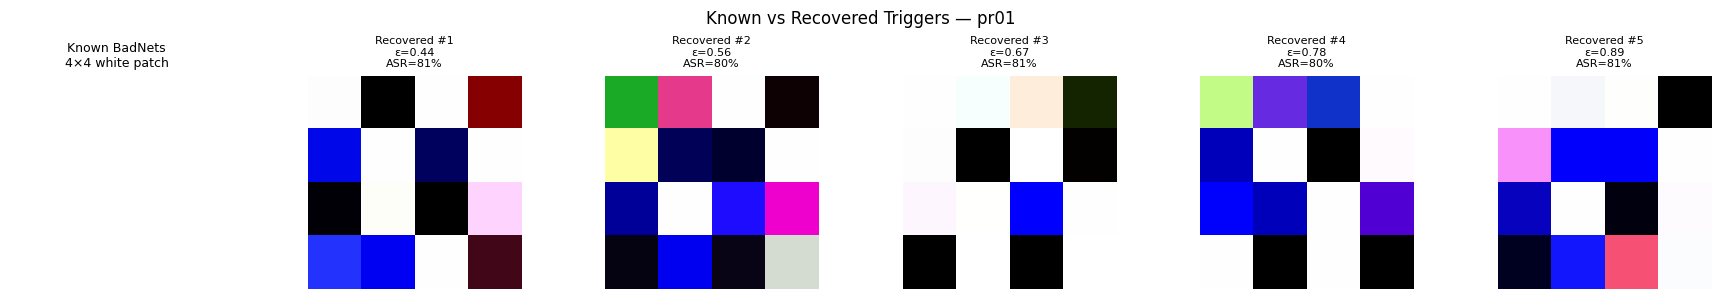

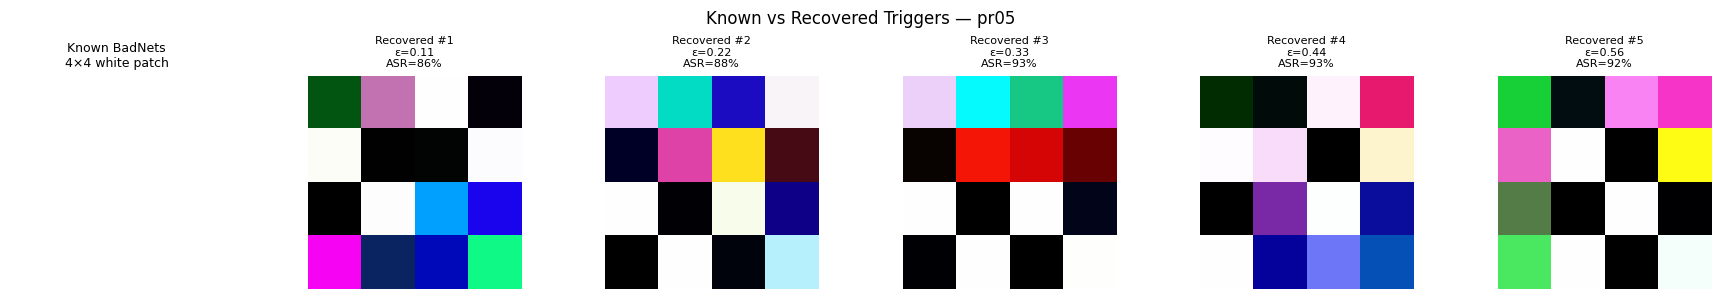

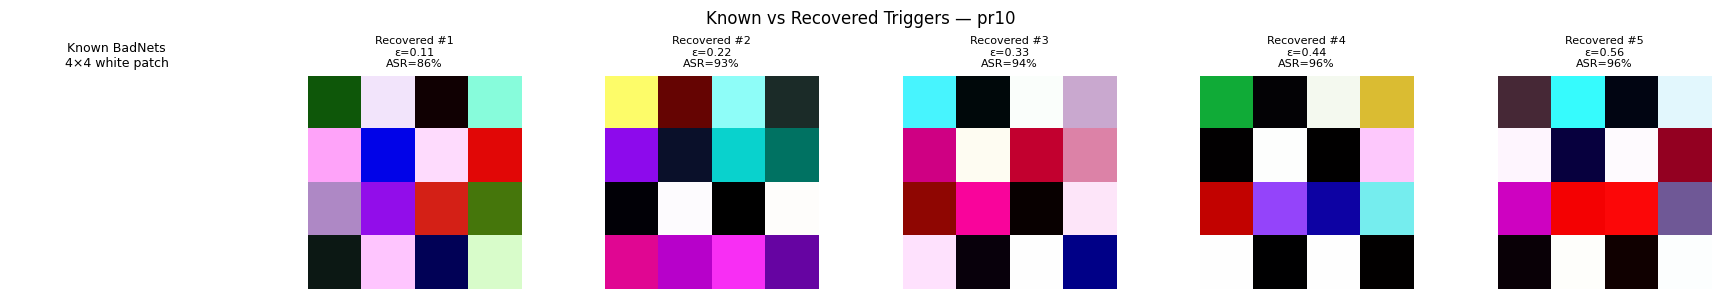

In [37]:
# ════════════════════════════════════════════════════════════════════════
# Cell L1 — Known Trigger vs Recovered Triggers
# ════════════════════════════════════════════════════════════════════════

# Create the known BadNets trigger (4×4 white patch)
known_trigger = np.ones((TRIGGER_SIZE, TRIGGER_SIZE, 3), dtype=np.float32)

for _tag in PR_TAGS:
    tp = all_trigger_pools.get(_tag, [])
    if not tp:
        print(f'{_tag}: No recovered triggers to compare.')
        continue

    n_recovered = min(len(tp), 5)
    fig, axes = plt.subplots(1, 1 + n_recovered, figsize=(3*(1+n_recovered), 3))

    # Known trigger
    axes[0].imshow(known_trigger, interpolation='nearest')
    axes[0].set_title('Known BadNets\n4×4 white patch', fontsize=9)
    axes[0].axis('off')

    # Recovered triggers (exact tensors)
    for i in range(n_recovered):
        trig = tp[i]['tensor'].view(
            3, BAERASER_TRIGGER_HEIGHT, BAERASER_TRIGGER_WIDTH
        ).permute(1, 2, 0).numpy().clip(0, 1)
        axes[i+1].imshow(trig, interpolation='nearest')
        axes[i+1].set_title(
            f'Recovered #{i+1}\nε={tp[i]["epsilon"]:.2f}\n'
            f'ASR={tp[i]["asr"]*100:.0f}%', fontsize=8)
        axes[i+1].axis('off')

    plt.suptitle(f'Known vs Recovered Triggers — {_tag}', fontsize=12)
    plt.tight_layout()
    save_path = f'{BAERASER_TRIGGER_FIG_DIR}/trigger_comparison_{_tag}.png',
    plt.savefig(save_path[0] if isinstance(save_path, tuple) else save_path, dpi=150, bbox_inches='tight')
    plt.show()

---
## Section M — Final Scientific Conclusion

In [38]:
# ════════════════════════════════════════════════════════════════════════
# Cell M1 — Metadata + Checkpoint Summary
# ════════════════════════════════════════════════════════════════════════
metadata = {
    'defense_method': 'BaEraser (Liu et al., IEEE INFOCOM 2022)',
    'paper': 'arXiv:2201.09538',
    'defense_samples': len(defense_set),
    'seed': SEED,
    'torch_version': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'device': str(DEVICE),
    'attack': ATTACK_NAME,
    'target_class': TARGET_CLASS,
    'trigger_size': TRIGGER_SIZE,
    'poison_rates': POISON_RATES,
    'trigger_recovery': {
        'trigger_height': BAERASER_TRIGGER_HEIGHT,
        'trigger_width': BAERASER_TRIGGER_WIDTH,
        'trigger_dim': BAERASER_TRIGGER_DIM,
        'g_input_dim': BAERASER_G_INPUT_DIM,
        'g_hidden': BAERASER_G_HIDDEN,
        'lr': BAERASER_TRIGGER_LR,
        'epochs': BAERASER_TRIGGER_EPOCHS,
        'eta': BAERASER_ETA,
        'epsilon_count': BAERASER_EPSILON_COUNT,
        'recovery_asr_threshold': BAERASER_RECOVERY_ASR_THRESHOLD,
        'placement': BAERASER_RECOVERY_PLACEMENT,
        'recovery_mode': BAERASER_RECOVERY_MODE,
    },
    'unlearning': {
        'alpha': BAERASER_ALPHA,
        'beta': BAERASER_BETA,
        'beta_alpha_ratio': round(BAERASER_BETA / BAERASER_ALPHA, 6),
        'lr': BAERASER_UNLEARN_LR,
        'momentum': BAERASER_UNLEARN_MOMENTUM,
        'max_epochs': BAERASER_MAX_UNLEARNING_EPOCHS,
        'asr_stop_threshold': BAERASER_ASR_STOP_THRESHOLD,
        'ca_drop_tolerance': CA_DROP_TOLERANCE,
    },
}
with open(f'{BAERASER_LOG_DIR}/baeraser_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved: {BAERASER_LOG_DIR}/baeraser_metadata.json')

print(f'\nCheckpoint Summary:')
for _tag in PR_TAGS:
    print(f'  {_tag}:')
    _p = f'{BAERASER_CKPT_DIR}/resnet18_badnets_{_tag}_baeraser.pth'
    _ok = os.path.isfile(_p)
    _sz = os.path.getsize(_p)/1e6 if _ok else 0
    print(f'    baeraser  {"ok" if _ok else "MISSING":7s}  {_sz:.1f} MB')

Metadata saved: /content/drive/MyDrive/Capstone/BadNets_Final/defense/baeraser/logs/baeraser_metadata.json

Checkpoint Summary:
  pr01:
    baeraser  ok       44.8 MB
  pr05:
    baeraser  ok       44.8 MB
  pr10:
    baeraser  ok       44.8 MB


In [39]:
# ════════════════════════════════════════════════════════════════════════
# Cell M2 — Conclusions
# ════════════════════════════════════════════════════════════════════════
print('='*65)
print(f'FINAL CONCLUSIONS — BaEraser Defence for BadNets')
print('='*65)

for _tag in PR_TAGS:
    _r = all_results[_tag]
    print(f'\nPoison rate: {PR_MAP[_tag]*100:.0f}% ({_tag})  Status: {_r.get("status", "?")}')
    print(f'  Before: CA={_r["CA_before"]*100:.2f}%  ASR={_r["ASR_before"]*100:.2f}%')
    if _r.get('CA_after') is not None:
        print(f'  After:  CA={_r["CA_after"]*100:.2f}%  ASR={_r["ASR_after"]*100:.2f}%')
        print(f'  CA drop:       {_r.get("CA_drop",0)*100:.2f} pp')
        print(f'  ASR reduction: {_r.get("ASR_reduction_abs",0)*100:.2f} pp '
              f'({_r.get("ASR_reduction_rel",0):.1f}%)')
        print(f'  Accepted triggers: {len(all_trigger_pools.get(_tag, []))}')
        print(f'  Unlearning epochs: {_r.get("best_epoch", "N/A")}')
    else:
        print(f'  FAILED: {_r.get("status", "unknown")}')

print(f'\n{"="*65}')
print('Defence approach:')
print('  "We do not simply fine-tune or prune the compromised network.')
print('   We first reconstruct the trigger distribution from the victim model,')
print('   then reverse the backdoor learning process using gradient-ascent')
print('   machine unlearning, while a dynamic clean-data gradient penalty')
print('   protects useful model knowledge."')
print(f'\nβ/α ratio: {BAERASER_BETA/BAERASER_ALPHA:.4f}')
print(f'Artifact root: {BAERASER_DIR}')
print('='*65)

FINAL CONCLUSIONS — BaEraser Defence for BadNets

Poison rate: 1% (pr01)  Status: SUCCESS
  Before: CA=90.28%  ASR=82.70%
  After:  CA=87.26%  ASR=0.80%
  CA drop:       3.02 pp
  ASR reduction: 81.90 pp (99.0%)
  Accepted triggers: 5
  Unlearning epochs: 13

Poison rate: 5% (pr05)  Status: SUCCESS
  Before: CA=89.81%  ASR=95.40%
  After:  CA=86.70%  ASR=0.90%
  CA drop:       3.11 pp
  ASR reduction: 94.50 pp (99.1%)
  Accepted triggers: 9
  Unlearning epochs: 15

Poison rate: 10% (pr10)  Status: SUCCESS
  Before: CA=89.59%  ASR=96.10%
  After:  CA=86.72%  ASR=0.90%
  CA drop:       2.87 pp
  ASR reduction: 95.20 pp (99.1%)
  Accepted triggers: 9
  Unlearning epochs: 14

Defence approach:
  "We do not simply fine-tune or prune the compromised network.
   We first reconstruct the trigger distribution from the victim model,
   then reverse the backdoor learning process using gradient-ascent
   machine unlearning, while a dynamic clean-data gradient penalty
   protects useful model knowl